# Time-Series Forecasting

Compares Facebook Prophet, Holt linear trend (additive, non-seasonal), and auto-ARIMA against naive last-value baselines using expanding-window cross-validation on 31 weekly observations (May–November 2025) for the 6 largest clusters.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings, logging, sys
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from prophet import Prophet
import seaborn as sns
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

plt.rcParams['figure.dpi'] = 120

NAVY      = '#003366'
NAIVE_C   = '#4A4A4A'
PROPHET_C = '#CC6600'
ETS_C     = '#2E7D32'
SARIMA_C  = '#C62828'

try:
    from pmdarima import auto_arima
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print('[INFO] pmdarima not installed — SARIMA will be skipped.')

_nb = globals().get('__vsc_ipynb_file__', None)
if _nb:
    REPO_ROOT = Path(_nb).parent.parent
else:
    _cwd = Path.cwd()
    REPO_ROOT = _cwd if (_cwd / 'gcp_config.py').exists() else _cwd.parent

OUT_DIR = REPO_ROOT / 'data'
OUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = OUT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))
from gcp_config import PROJECT_ID, bq_table
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

weekly_vol = client.query(f"""
    SELECT week_start AS week, total_conversations AS total
    FROM `{bq_table('weekly_volume')}`
    ORDER BY week_start
""").to_dataframe()
weekly_vol['week'] = pd.to_datetime(weekly_vol['week'])

df_ct = client.query(f"""
    SELECT week_start AS week, cluster_id, chunk_count, conversation_count
    FROM `{bq_table('chunk_cluster_trends')}`
    ORDER BY cluster_id, week_start
""").to_dataframe()
df_ct['week'] = pd.to_datetime(df_ct['week'])

df = client.query(f"""
    SELECT DISTINCT
        cl.conversation_id,
        cl.cluster_id,
        DATE(d.conversation_start_date) AS conversation_date,
        d.client_message_count,
        d.total_message_count,
        d.rating_score,
        d.detected_language
    FROM `{bq_table('chunk_cluster_labels')}` cl
    JOIN `{bq_table('conversation_docs')}` d USING (conversation_id)
    WHERE NOT cl.is_noise
""").to_dataframe()
df['conversation_date'] = pd.to_datetime(df['conversation_date'])
df['week'] = df['conversation_date'].dt.to_period('W').dt.start_time
df_c = df.copy()

weekly = weekly_vol.rename(columns={'week': 'week'})
top_clusters = df_ct.groupby('cluster_id')['chunk_count'].sum().nlargest(6).index.tolist()
print(f'Weeks: {len(weekly)}  |  Date range: {df.conversation_date.min().date()} → {df.conversation_date.max().date()}')
print(f'Top clusters by chunk volume: {top_clusters}')

Weeks: 31  |  Date range: 2025-05-01 → 2025-11-29
Top clusters by chunk volume: [11, 8, 20, 16, 13, 15]


In [2]:
titles_df = client.query(f"""
    SELECT cluster_id, cluster_title
    FROM `{bq_table('chunk_cluster_descriptions')}`
    ORDER BY cluster_id
""").to_dataframe()
titles_dict = dict(zip(titles_df['cluster_id'], titles_df['cluster_title']))
print(f"Loaded {len(titles_df)} cluster titles")
print("Top clusters:", {cid: titles_dict.get(cid, f'C{cid}') for cid in top_clusters})

Loaded 24 cluster titles
Top clusters: {11: 'Domain Purchase and Registration', 8: 'Human Agent Escalation Requests', 20: 'Website Down HTTP Error Diagnosis', 16: 'AI Builder Site Generation Editing', 13: 'Account and WordPress Login', 15: 'AI Builder Layout and Styling'}


## 1. Seasonal decomposition (total volume)

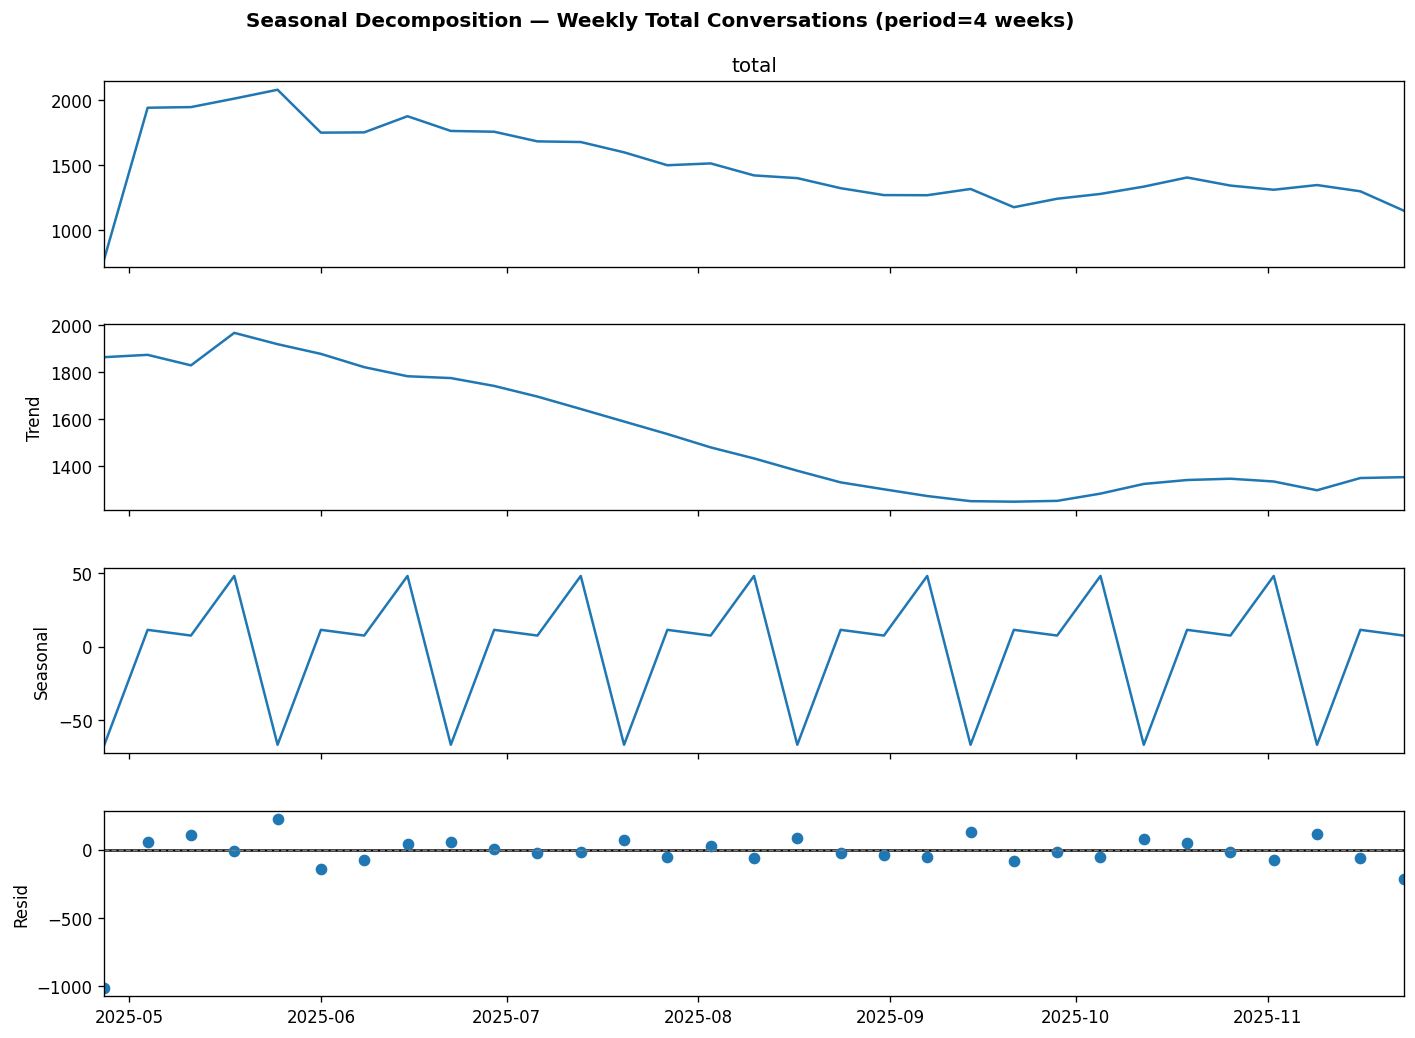

In [3]:
series = weekly.set_index('week')['total']
if len(series) >= 8:
    decomp = seasonal_decompose(series, model='additive', period=4, extrapolate_trend='freq')
    fig = decomp.plot()
    fig.set_size_inches(13, 9)
    fig.axes[-1].axhline(0, color='grey', ls='--', lw=0.8)
    fig.suptitle('Seasonal Decomposition — Weekly Total Conversations (period=4 weeks)',
                 fontsize=12, fontweight='bold', y=0.995)
    plt.subplots_adjust(top=0.93)
    plt.savefig(FIGURES_DIR / 'decomposition.png', bbox_inches='tight')
    plt.show()
else:
    print('Not enough weeks')

## 2. ADF stationarity tests

ADF Stationarity Tests — chunk volume per cluster (p < 0.05 → stationary):
  C11 ( 10587 chunks):  ADF=-3.562  p=0.0065  → STATIONARY
  C 8 ( 10150 chunks):  ADF=-2.617  p=0.0895  → non-stationary
  C20 (  8767 chunks):  ADF=-0.679  p=0.8520  → non-stationary
  C16 (  8733 chunks):  ADF=-2.239  p=0.1925  → non-stationary
  C13 (  7951 chunks):  ADF=-2.182  p=0.2128  → non-stationary
  C15 (  7893 chunks):  ADF=-3.058  p=0.0298  → STATIONARY

Ljung-Box Test for Autocorrelation (aggregate weekly volume):
  Lag 1: Q=11.56  p=0.0007  → SIGNIFICANT
  Lag 2: Q=20.44  p=0.0000  → SIGNIFICANT
  Lag 3: Q=26.78  p=0.0000  → SIGNIFICANT
  Lag 4: Q=29.97  p=0.0000  → SIGNIFICANT


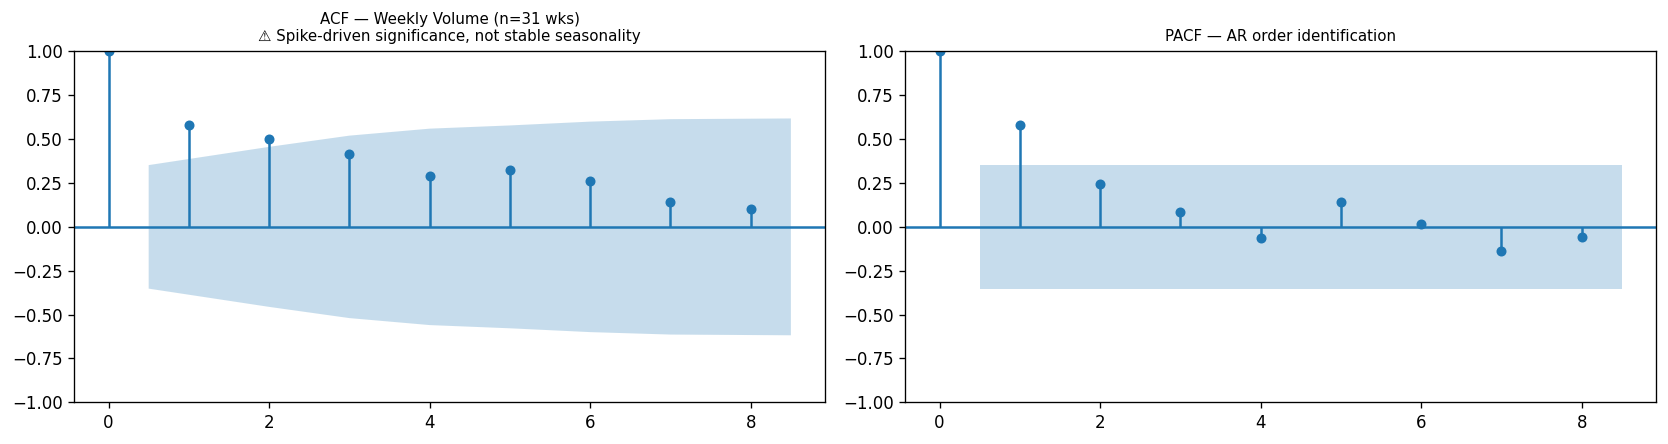


Engle ARCH-LM test — does variance cluster? (GARCH only warranted if p < 0.05):
  Aggregate volume: LM=24.687  p=0.0001  → ARCH effects present → volatility clusters; GARCH improves CI width


In [5]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

all_weeks = pd.DatetimeIndex(sorted(weekly_vol['week'].unique()))

print('ADF Stationarity Tests — chunk volume per cluster (p < 0.05 → stationary):')
for cid in top_clusters:
    s = (df_ct[df_ct.cluster_id == cid]
         .set_index('week')['chunk_count']
         .reindex(all_weeks, fill_value=0)
         .sort_index())
    if len(s) < 8:
        print(f'  Cluster {cid}: too few weeks')
        continue
    if float(s.max()) == float(s.min()):
        print(f'  C{cid:2d}: constant chunk counts across weeks — skip ADF')
        continue
    stat, p, *_ = adfuller(s)
    print(f'  C{cid:2d} ({int(s.sum()):6d} chunks):  ADF={stat:.3f}  p={p:.4f}  '
          f'→ {"STATIONARY" if p < 0.05 else "non-stationary"}')

print('\nLjung-Box Test for Autocorrelation (aggregate weekly volume):')
agg_series = weekly.set_index('week')['total']
if len(agg_series) >= 8:
    lb = acorr_ljungbox(agg_series, lags=[1, 2, 3, 4], return_df=True)
    for lag, row in lb.iterrows():
        sig = 'SIGNIFICANT' if row['lb_pvalue'] < 0.05 else 'not significant'
        print(f'  Lag {lag}: Q={row["lb_stat"]:.2f}  p={row["lb_pvalue"]:.4f}  → {sig}')

    # ACF: decaying slowly → non-stationary / trend; cutting off at lag 0 after
    #      differencing → random walk → Naive is provably optimal.
    # PACF: identifies AR order — cutoff at lag k means AR(k) is sufficient.
    fig, (ax_acf, ax_pacf) = plt.subplots(1, 2, figsize=(14, 3.8))
    plot_acf(agg_series, lags=min(len(agg_series) // 2 - 1, 8), ax=ax_acf)
    ax_acf.set_title(
        f'ACF — Weekly Volume (n={len(agg_series)} wks)\n'
        '⚠ Spike-driven significance, not stable seasonality',
        fontsize=9)
    plot_pacf(agg_series, lags=min(len(agg_series) // 2 - 1, 8), ax=ax_pacf, method='ywm')
    ax_pacf.set_title('PACF — AR order identification', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'acf_pacf_plot.png', bbox_inches='tight')
    plt.show()

    # Engle ARCH-LM test, is GARCH warranted? 
    # GARCH models conditional *variance* (volatility clustering), not the mean.
    # It does NOT improve point forecasts — only confidence intervals.
    # It also requires 100+ observations; we have ~31. Only use if p < 0.05 here.
    print('\nEngle ARCH-LM test — does variance cluster? (GARCH only warranted if p < 0.05):')
    try:
        arch_lm, arch_p, _, _ = het_arch(agg_series.dropna().values, nlags=4)
        if arch_p < 0.05:
            verdict = 'ARCH effects present → volatility clusters; GARCH improves CI width'
        else:
            verdict = 'no ARCH effects → GARCH does NOT improve point forecasts here'
        print(f'  Aggregate volume: LM={arch_lm:.3f}  p={arch_p:.4f}  → {verdict}')
    except Exception as e:
        print(f'  [ARCH-LM error] {e}')
else:
    print('  Not enough data points for Ljung-Box test')

## 3. Prophet models with hold-out evaluation

In [7]:
from sklearn.metrics import mean_squared_error
from scipy import stats as sp_stats

MIN_TRAIN = 8
HOLDOUT   = 3
FWD       = 4

def smape(actual, pred):
    return float(100 * np.mean(2 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + 1e-8)))

def diebold_mariano(actual, pred1, pred2):
    e1, e2 = actual - pred1, actual - pred2
    d = e1**2 - e2**2
    n = len(d)
    if n < 3 or np.var(d, ddof=1) < 1e-10:
        return np.nan, np.nan
    dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / n)
    p_val = 2 * (1 - sp_stats.t.cdf(abs(dm_stat), df=n - 1))
    return round(dm_stat, 3), round(p_val, 4)

all_cv_rows = []
print('Expanding-window CV (1-step-ahead, min_train=8 weeks) — CHUNK VOLUME')

for cid in top_clusters:
    s = (df_ct[df_ct.cluster_id == cid][['week', 'chunk_count']]
         .rename(columns={'week': 'ds', 'chunk_count': 'y'})
         .sort_values('ds').reset_index(drop=True))
    s['ds'] = pd.to_datetime(s['ds'])
    if len(s) < MIN_TRAIN + 1:
        continue

    fold_results = []
    for split in range(MIN_TRAIN, len(s)):
        train = s.iloc[:split].copy()
        actual_val = s.iloc[split]['y']

        m = Prophet(weekly_seasonality=False, daily_seasonality=False,
                    yearly_seasonality=False, changepoint_prior_scale=0.1)
        m.fit(train)
        future = m.make_future_dataframe(periods=1, freq='7D')
        fcst = m.predict(future)
        p_pred = max(fcst['yhat'].iloc[-1], 0)

        n_last = float(train['y'].iloc[-1])
        n_ma4  = float(train['y'].iloc[-4:].mean())

        fold_results.append({
            'fold': split, 'actual': actual_val,
            'prophet': p_pred, 'naive_last': n_last, 'naive_ma4': n_ma4,
        })

    fdf = pd.DataFrame(fold_results)
    a = fdf['actual'].values
    pp = fdf['prophet'].values
    nl = fdf['naive_last'].values

    mae_p  = mean_absolute_error(a, pp)
    rmse_p = np.sqrt(mean_squared_error(a, pp))
    smp_p  = smape(a, pp)
    mae_nl = mean_absolute_error(a, nl)
    mae_ma = mean_absolute_error(a, fdf['naive_ma4'].values)
    dm_stat, dm_p = diebold_mariano(a, pp, nl)

    all_cv_rows.append({
        'cluster_id': cid, 'n_weeks': len(s), 'cv_folds': len(fdf),
        'prophet_mae': round(mae_p, 2), 'prophet_rmse': round(rmse_p, 2),
        'prophet_smape': round(smp_p, 1),
        'naive_last_mae': round(mae_nl, 2), 'naive_ma4_mae': round(mae_ma, 2),
        'better_than_naive': mae_p < min(mae_nl, mae_ma),
        'dm_stat_vs_naive': dm_stat, 'dm_pvalue_vs_naive': dm_p,
    })
    sig = f'DM p={dm_p}' if dm_p is not np.nan else 'DM N/A'
    print(f'C{cid:2d} ({len(fdf)} folds): MAE={mae_p:.2f}  naive={mae_nl:.2f}  {sig}  [chunks/week]')

fcst_df = pd.DataFrame(all_cv_rows)
fcst_df.to_csv(RESULTS_DIR / 'forecast_accuracy.csv', index=False)
print('\n', fcst_df.to_string(index=False))

23:57:58 - cmdstanpy - INFO - Chain [1] start processing
23:57:58 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing


Expanding-window CV (1-step-ahead, min_train=8 weeks) — CHUNK VOLUME


23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing
23:57:59 - cmdstanpy - INFO - Chain [1] 

C11 (23 folds): MAE=59.15  naive=37.61  DM p=0.1055  [chunks/week]


23:58:02 - cmdstanpy - INFO - Chain [1] start processing
23:58:02 - cmdstanpy - INFO - Chain [1] done processing
23:58:02 - cmdstanpy - INFO - Chain [1] start processing
23:58:02 - cmdstanpy - INFO - Chain [1] done processing
23:58:02 - cmdstanpy - INFO - Chain [1] start processing
23:58:02 - cmdstanpy - INFO - Chain [1] done processing
23:58:02 - cmdstanpy - INFO - Chain [1] start processing
23:58:02 - cmdstanpy - INFO - Chain [1] done processing
23:58:02 - cmdstanpy - INFO - Chain [1] start processing
23:58:02 - cmdstanpy - INFO - Chain [1] done processing
23:58:02 - cmdstanpy - INFO - Chain [1] start processing
23:58:03 - cmdstanpy - INFO - Chain [1] done processing
23:58:03 - cmdstanpy - INFO - Chain [1] start processing
23:58:03 - cmdstanpy - INFO - Chain [1] done processing
23:58:03 - cmdstanpy - INFO - Chain [1] start processing
23:58:03 - cmdstanpy - INFO - Chain [1] done processing
23:58:03 - cmdstanpy - INFO - Chain [1] start processing
23:58:03 - cmdstanpy - INFO - Chain [1]

...

C16 (23 folds): MAE=41.03  naive=50.96  DM p=0.3041  [chunks/week]


23:58:12 - cmdstanpy - INFO - Chain [1] start processing
23:58:12 - cmdstanpy - INFO - Chain [1] done processing
23:58:12 - cmdstanpy - INFO - Chain [1] start processing
23:58:12 - cmdstanpy - INFO - Chain [1] done processing
23:58:12 - cmdstanpy - INFO - Chain [1] start processing
23:58:12 - cmdstanpy - INFO - Chain [1] done processing
23:58:12 - cmdstanpy - INFO - Chain [1] start processing
23:58:12 - cmdstanpy - INFO - Chain [1] done processing
23:58:12 - cmdstanpy - INFO - Chain [1] start processing
23:58:12 - cmdstanpy - INFO - Chain [1] done processing
23:58:13 - cmdstanpy - INFO - Chain [1] start processing
23:58:13 - cmdstanpy - INFO - Chain [1] done processing
23:58:13 - cmdstanpy - INFO - Chain [1] start processing
23:58:13 - cmdstanpy - INFO - Chain [1] done processing
23:58:13 - cmdstanpy - INFO - Chain [1] start processing
23:58:13 - cmdstanpy - INFO - Chain [1] done processing
23:58:13 - cmdstanpy - INFO - Chain [1] start processing
23:58:13 - cmdstanpy - INFO - Chain [1]

C13 (23 folds): MAE=47.50  naive=48.35  DM p=0.7012  [chunks/week]


23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1] done processing
23:58:15 - cmdstanpy - INFO - Chain [1] start processing
23:58:15 - cmdstanpy - INFO - Chain [1]

C15 (23 folds): MAE=36.80  naive=33.78  DM p=0.4825  [chunks/week]

  cluster_id  n_weeks  cv_folds  prophet_mae  prophet_rmse  prophet_smape  naive_last_mae  naive_ma4_mae  better_than_naive  dm_stat_vs_naive  dm_pvalue_vs_naive
         11       31        23        59.15         69.85           17.3           37.61          49.22              False             1.688              0.1055
          8       31        23        51.13         57.55           15.8           30.70          28.75              False             3.565              0.0017
         20       31        23        43.47         53.60           14.4           22.35          24.01              False             3.258              0.0036
         16       31        23        41.03         51.92           14.9           50.96          35.03              False            -1.052              0.3041
         13       31        23        47.50         60.91           19.0           48.35          43.29              False    

## 4. Multi-model forecasting comparison: Prophet vs SARIMA vs Holt ETS

In [10]:
def ets_predict_one(train_vals):
    try:
        model = ExponentialSmoothing(
            train_vals.astype(float), trend='add', seasonal=None,
            initialization_method='estimated')
        fit = model.fit(optimized=True, use_brute=True)
        return max(fit.forecast(1)[0], 0)
    except Exception:
        return np.nan

def sarima_predict_one(train_vals):
    if not PMDARIMA_AVAILABLE:
        return np.nan
    try:
        model = auto_arima(
            train_vals.astype(float),
            start_p=0, max_p=3, start_q=0, max_q=3, d=None,
            seasonal=False, information_criterion='aic',
            error_action='ignore', suppress_warnings=True)
        return max(model.predict(1)[0], 0)
    except Exception:
        return np.nan

all_model_rows = []
print('Multi-model expanding-window CV (Prophet vs ETS vs SARIMA vs Naive) — CHUNK VOLUME')
print('DM test: two-sided p-values via t(df=n_folds-1), Harvey–Leybourne–Newbold (1997).')
print('(Normal approx. would be slightly anti-conservative; t is conservative vs naive.)')

for cid in top_clusters:
    s = (df_ct[df_ct.cluster_id == cid][['week', 'chunk_count']]
         .rename(columns={'week': 'ds', 'chunk_count': 'y'})
         .sort_values('ds').reset_index(drop=True))
    s['ds'] = pd.to_datetime(s['ds'])
    if len(s) < MIN_TRAIN + 1:
        continue

    folds = []
    for split in range(MIN_TRAIN, len(s)):
        train = s.iloc[:split]
        actual_val = s.iloc[split]['y']

        m = Prophet(weekly_seasonality=False, daily_seasonality=False,
                    yearly_seasonality=False, changepoint_prior_scale=0.1)
        m.fit(train.copy())
        future = m.make_future_dataframe(periods=1, freq='7D')
        fcst = m.predict(future)
        p_pred = max(fcst['yhat'].iloc[-1], 0)

        e_pred = ets_predict_one(train['y'].values)
        s_pred = sarima_predict_one(train['y'].values)

        n_last = float(train['y'].iloc[-1])
        n_ma4  = float(train['y'].iloc[-4:].mean())

        folds.append({
            'actual': actual_val, 'prophet': p_pred, 'ets': e_pred,
            'sarima': s_pred, 'naive_last': n_last, 'naive_ma4': n_ma4,
        })

    fdf = pd.DataFrame(folds)
    a  = fdf['actual'].values
    nl = fdf['naive_last'].values

    model_maes = {}
    for mname in ['prophet', 'ets', 'sarima', 'naive_last', 'naive_ma4']:
        pv = fdf[mname].values
        valid = ~np.isnan(pv)
        model_maes[mname] = mean_absolute_error(a[valid], pv[valid]) if valid.sum() > 0 else np.nan

    best = min(
        (k for k in ['prophet', 'ets', 'sarima'] if not np.isnan(model_maes.get(k, np.nan))),
        key=lambda k: model_maes[k], default='N/A')

    row = {'cluster_id': cid, 'n_weeks': len(s), 'cv_folds': len(fdf), 'best_model': best.title()}
    for mname in ['prophet', 'ets', 'sarima', 'naive_last', 'naive_ma4']:
        pv = fdf[mname].values
        valid = ~np.isnan(pv)
        if valid.sum() == 0:
            row[f'{mname}_mae'] = row[f'{mname}_rmse'] = row[f'{mname}_smape'] = np.nan
            continue
        row[f'{mname}_mae']   = round(mean_absolute_error(a[valid], pv[valid]), 2)
        row[f'{mname}_rmse']  = round(np.sqrt(mean_squared_error(a[valid], pv[valid])), 2)
        row[f'{mname}_smape'] = round(smape(a[valid], pv[valid]), 1)

    dm_stat_p, dm_p_p = diebold_mariano(a, fdf['prophet'].values, nl)
    row['dm_stat_prophet_vs_naive']  = dm_stat_p
    row['dm_pvalue_prophet_vs_naive'] = dm_p_p

    for mname, sfx in [('ets', 'ets'), ('sarima', 'sarima')]:
        pv     = fdf[mname].values
        valid_m = ~np.isnan(pv)
        if valid_m.sum() >= 3:
            dm_stat_m, dm_p_m = diebold_mariano(a[valid_m], pv[valid_m], nl[valid_m])
        else:
            dm_stat_m, dm_p_m = np.nan, np.nan
        row[f'dm_stat_{sfx}_vs_naive']   = dm_stat_m
        row[f'dm_pvalue_{sfx}_vs_naive'] = dm_p_m

    all_model_rows.append(row)
    print(f'C{cid:2d} ({len(fdf)} folds)  '
          f'Prophet={row["prophet_mae"]:.2f}  ETS={row.get("ets_mae","N/A")}  '
          f'SARIMA={row.get("sarima_mae","N/A")}  Naive={row["naive_last_mae"]:.2f}  '
          f'→ {best.title()}  |  DM p: P={row["dm_pvalue_prophet_vs_naive"]:.3f}  '
          f'E={row.get("dm_pvalue_ets_vs_naive", float("nan")):.3f}  '
          f'S={row.get("dm_pvalue_sarima_vs_naive", float("nan")):.3f}')

model_comp_df = pd.DataFrame(all_model_rows)
model_comp_df.to_csv(RESULTS_DIR / 'forecasting_model_comparison.csv', index=False)
print('\nSaved: data/forecasting_model_comparison.csv')
display_cols = [c for c in [
    'cluster_id', 'cv_folds', 'prophet_mae', 'ets_mae', 'sarima_mae', 'naive_last_mae',
    'best_model', 'dm_pvalue_prophet_vs_naive', 'dm_pvalue_ets_vs_naive',
    'dm_pvalue_sarima_vs_naive'] if c in model_comp_df.columns]
print('\n', model_comp_df[display_cols].to_string(index=False))

00:03:13 - cmdstanpy - INFO - Chain [1] start processing
00:03:13 - cmdstanpy - INFO - Chain [1] done processing


Multi-model expanding-window CV (Prophet vs ETS vs SARIMA vs Naive) — CHUNK VOLUME
DM test: two-sided p-values via t(df=n_folds-1), Harvey–Leybourne–Newbold (1997).
(Normal approx. would be slightly anti-conservative; t is conservative vs naive.)


00:03:13 - cmdstanpy - INFO - Chain [1] start processing
00:03:13 - cmdstanpy - INFO - Chain [1] done processing
00:03:14 - cmdstanpy - INFO - Chain [1] start processing
00:03:14 - cmdstanpy - INFO - Chain [1] done processing
00:03:14 - cmdstanpy - INFO - Chain [1] start processing
00:03:15 - cmdstanpy - INFO - Chain [1] done processing
00:03:15 - cmdstanpy - INFO - Chain [1] start processing
00:03:15 - cmdstanpy - INFO - Chain [1] done processing
00:03:16 - cmdstanpy - INFO - Chain [1] start processing
00:03:16 - cmdstanpy - INFO - Chain [1] done processing
00:03:16 - cmdstanpy - INFO - Chain [1] start processing
00:03:16 - cmdstanpy - INFO - Chain [1] done processing
00:03:17 - cmdstanpy - INFO - Chain [1] start processing
00:03:17 - cmdstanpy - INFO - Chain [1] done processing
00:03:17 - cmdstanpy - INFO - Chain [1] start processing
00:03:17 - cmdstanpy - INFO - Chain [1] done processing
00:03:18 - cmdstanpy - INFO - Chain [1] start processing
00:03:18 - cmdstanpy - INFO - Chain [1]

C11 (23 folds)  Prophet=59.15  ETS=56.15  SARIMA=53.87  Naive=37.61  → Sarima  |  DM p: P=0.105  E=0.098  S=0.360


00:03:29 - cmdstanpy - INFO - Chain [1] start processing
00:03:29 - cmdstanpy - INFO - Chain [1] done processing
00:03:30 - cmdstanpy - INFO - Chain [1] start processing
00:03:30 - cmdstanpy - INFO - Chain [1] done processing
00:03:30 - cmdstanpy - INFO - Chain [1] start processing
00:03:30 - cmdstanpy - INFO - Chain [1] done processing
00:03:31 - cmdstanpy - INFO - Chain [1] start processing
00:03:31 - cmdstanpy - INFO - Chain [1] done processing
00:03:31 - cmdstanpy - INFO - Chain [1] start processing
00:03:31 - cmdstanpy - INFO - Chain [1] done processing
00:03:32 - cmdstanpy - INFO - Chain [1] start processing
00:03:32 - cmdstanpy - INFO - Chain [1] done processing
00:03:32 - cmdstanpy - INFO - Chain [1] start processing
00:03:32 - cmdstanpy - INFO - Chain [1] done processing
00:03:33 - cmdstanpy - INFO - Chain [1] start processing
00:03:33 - cmdstanpy - INFO - Chain [1] done processing
00:03:34 - cmdstanpy - INFO - Chain [1] start processing
00:03:34 - cmdstanpy - INFO - Chain [1]

...

C16 (23 folds)  Prophet=41.03  ETS=40.93  SARIMA=45.36  Naive=50.96  → Ets  |  DM p: P=0.304  E=0.295  S=0.568


00:04:36 - cmdstanpy - INFO - Chain [1] start processing
00:04:36 - cmdstanpy - INFO - Chain [1] done processing
00:04:37 - cmdstanpy - INFO - Chain [1] start processing
00:04:37 - cmdstanpy - INFO - Chain [1] done processing
00:04:37 - cmdstanpy - INFO - Chain [1] start processing
00:04:38 - cmdstanpy - INFO - Chain [1] done processing
00:04:38 - cmdstanpy - INFO - Chain [1] start processing
00:04:38 - cmdstanpy - INFO - Chain [1] done processing
00:04:39 - cmdstanpy - INFO - Chain [1] start processing
00:04:39 - cmdstanpy - INFO - Chain [1] done processing
00:04:40 - cmdstanpy - INFO - Chain [1] start processing
00:04:40 - cmdstanpy - INFO - Chain [1] done processing
00:04:41 - cmdstanpy - INFO - Chain [1] start processing
00:04:41 - cmdstanpy - INFO - Chain [1] done processing
00:04:42 - cmdstanpy - INFO - Chain [1] start processing
00:04:42 - cmdstanpy - INFO - Chain [1] done processing
00:04:42 - cmdstanpy - INFO - Chain [1] start processing
00:04:43 - cmdstanpy - INFO - Chain [1]

C13 (23 folds)  Prophet=47.50  ETS=48.25  SARIMA=59.85  Naive=48.35  → Prophet  |  DM p: P=0.701  E=0.672  S=0.206


00:04:57 - cmdstanpy - INFO - Chain [1] start processing
00:04:57 - cmdstanpy - INFO - Chain [1] done processing
00:04:58 - cmdstanpy - INFO - Chain [1] start processing
00:04:58 - cmdstanpy - INFO - Chain [1] done processing
00:04:59 - cmdstanpy - INFO - Chain [1] start processing
00:04:59 - cmdstanpy - INFO - Chain [1] done processing
00:05:00 - cmdstanpy - INFO - Chain [1] start processing
00:05:00 - cmdstanpy - INFO - Chain [1] done processing
00:05:01 - cmdstanpy - INFO - Chain [1] start processing
00:05:01 - cmdstanpy - INFO - Chain [1] done processing
00:05:06 - cmdstanpy - INFO - Chain [1] start processing
00:05:06 - cmdstanpy - INFO - Chain [1] done processing
00:05:07 - cmdstanpy - INFO - Chain [1] start processing
00:05:07 - cmdstanpy - INFO - Chain [1] done processing
00:05:08 - cmdstanpy - INFO - Chain [1] start processing
00:05:08 - cmdstanpy - INFO - Chain [1] done processing
00:05:08 - cmdstanpy - INFO - Chain [1] start processing
00:05:08 - cmdstanpy - INFO - Chain [1]

C15 (23 folds)  Prophet=36.80  ETS=39.62  SARIMA=35.03  Naive=33.78  → Sarima  |  DM p: P=0.482  E=0.097  S=0.701

Saved: data/forecasting_model_comparison.csv

  cluster_id  cv_folds  prophet_mae  ets_mae  sarima_mae  naive_last_mae best_model  dm_pvalue_prophet_vs_naive  dm_pvalue_ets_vs_naive  dm_pvalue_sarima_vs_naive
         11        23        59.15    56.15       53.87           37.61     Sarima                      0.1055                  0.0981                     0.3604
          8        23        51.13    38.92       30.82           30.70     Sarima                      0.0017                  0.0375                     0.5443
         20        23        43.47    29.26       21.29           22.35     Sarima                      0.0036                  0.0432                     0.9475
         16        23        41.03    40.93       45.36           50.96        Ets                      0.3041                  0.2946                     0.5680
         13        23       

## 5. Visual comparison on the top cluster

In [14]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

SPIKE_END = 5 

def arimax_spike_predict_one(train_vals, spike_end=SPIKE_END):
    """ARIMAX with launch-spike dummy. Sets exog=0 at forecast step (always post-spike)."""
    if not PMDARIMA_AVAILABLE:
        return np.nan
    try:
        n = len(train_vals)
        spike_exog = np.zeros((n, 1))
        spike_exog[:min(spike_end, n), 0] = 1.0
        model = auto_arima(
            train_vals.astype(float),
            X=spike_exog,
            start_p=0, max_p=3, start_q=0, max_q=3, d=None,
            seasonal=False, information_criterion='aic',
            error_action='ignore', suppress_warnings=True)
        return max(float(model.predict(1, X=np.array([[0.0]]))[0]), 0)
    except Exception:
        return np.nan

def damped_ets_predict_one(train_vals):
    """One-step-ahead damped trend ETS (phi optimised by MLE)."""
    try:
        model = ExponentialSmoothing(
            train_vals.astype(float), trend='add', seasonal=None,
            damped_trend=True, initialization_method='estimated')
        fit = model.fit(optimized=True, use_brute=True)
        return max(float(fit.forecast(1)[0]), 0)
    except Exception:
        return np.nan

def rw_drift_predict_one(train_vals):
    """Random Walk with Drift = last value + mean(weekly Δ). ARIMA(0,1,0)+c."""
    try:
        if len(train_vals) < 2:
            return max(float(train_vals[-1]), 0)
        drift = np.mean(np.diff(train_vals.astype(float)))
        return max(float(train_vals[-1]) + drift, 0)
    except Exception:
        return np.nan

_cvol = df_ct[df_ct['cluster_id'].isin(top_clusters)].groupby('cluster_id')['chunk_count'].sum()
_vs   = (_cvol / _cvol.sum()).to_dict()

MODEL_COLS = ['naive_last', 'rw_drift', 'arimax_spike', 'damped_ets', 'ens_dn']
MODEL_LABELS = {
    'naive_last':   'Naive (last)',
    'rw_drift':     'RW + Drift (ARIMA(0,1,0)+c)',
    'arimax_spike': 'ARIMAX + spike dummy',
    'damped_ets':   'Damped ETS',
    'ens_dn':       'Ensemble (Damped+Naive)',
}

extra_rows = []
print('Extended CV: ARIMAX-spike + RW-Drift + Damped ETS + Damped-Naive Ensemble')
print(f'Spike dummy = 1 for weeks 1–{SPIKE_END} (May 2025 launch surge), 0 after.')

for cid in top_clusters:
    s = (df_ct[df_ct.cluster_id == cid][['week', 'chunk_count']]
         .rename(columns={'week': 'ds', 'chunk_count': 'y'})
         .sort_values('ds').reset_index(drop=True))
    s['ds'] = pd.to_datetime(s['ds'])
    if len(s) < MIN_TRAIN + 1:
        continue

    folds = []
    for split in range(MIN_TRAIN, len(s)):
        train_vals = s.iloc[:split]['y'].values
        actual_val = s.iloc[split]['y']
        n_last  = float(train_vals[-1])
        rw_pred = rw_drift_predict_one(train_vals)
        ax_pred = arimax_spike_predict_one(train_vals)
        d_pred  = damped_ets_predict_one(train_vals)
        folds.append({
            'actual':       actual_val,
            'naive_last':   n_last,
            'rw_drift':     rw_pred,
            'arimax_spike': ax_pred,
            'damped_ets':   d_pred,
            'ens_dn':       np.nanmean([d_pred, n_last]),
        })

    fdf = pd.DataFrame(folds)
    a   = fdf['actual'].values
    vol_share = _vs.get(cid, 0)
    row = {'cluster_id': cid, 'cv_folds': len(fdf), 'vol_share': vol_share,
           'cluster_title': titles_dict.get(cid, f'C{cid}')}
    for col in MODEL_COLS:
        pv    = fdf[col].values
        valid = ~np.isnan(pv)
        mae   = mean_absolute_error(a[valid], pv[valid]) if valid.sum() > 0 else np.nan
        row[f'{col}_mae'] = round(mae, 2)
    extra_rows.append(row)
    am = row.get('arimax_spike_mae', np.nan)
    nm = row.get('naive_last_mae', np.nan)
    beat = '  ✓ BEATS NAIVE' if (not np.isnan(am)) and am < nm else ''
    print(f'  C{cid:2d} ({vol_share*100:.1f}%):  '
          f'Naive={nm:.2f}  ARIMAX-spike={am:.2f}  '
          f'RW-Drift={row.get("rw_drift_mae", float("nan")):.2f}  '
          f'DampedETS={row.get("damped_ets_mae", float("nan")):.2f}{beat}')

extra_df = pd.DataFrame(extra_rows)

def wmae(df, col):
    v = df[col].notna()
    d = df.loc[v, 'vol_share'].sum()
    return (df.loc[v, col] * df.loc[v, 'vol_share']).sum() / d if d > 0 else np.nan

new_wmae = {MODEL_LABELS[c]: wmae(extra_df, f'{c}_mae') for c in MODEL_COLS}

existing_wmae = {}
if not model_comp_df.empty:
    _mc = model_comp_df.copy()
    _mc['vol_share'] = _mc['cluster_id'].map(_vs).fillna(0)
    for col, label in [('prophet_mae', 'Prophet'), ('ets_mae', 'ETS (Holt)'),
                       ('sarima_mae', 'Auto-ARIMA')]:
        if col in _mc.columns:
            v = _mc[col].notna()
            d = _mc.loc[v, 'vol_share'].sum()
            existing_wmae[label] = (
                (_mc.loc[v, col] * _mc.loc[v, 'vol_share']).sum() / d
                if d > 0 else np.nan)

all_wmae = {**existing_wmae, **new_wmae}
naive_ref = new_wmae['Naive (last)']

print('FULL MODEL COMPARISON — Volume-weighted MAE (chunks/week)')
print('Weighted MAE = Σ(cluster_MAE × cluster_chunk_share)')
print(f'  {"Model":<38}  {"wMAE":>7}  {"vs Naive":>9}')
print('  ' + '-' * 58)
for label, wm in sorted(all_wmae.items(), key=lambda x: x[1]):
    diff = wm - naive_ref
    flag = ' ← BASELINE'   if 'Naive (last)' == label else \
           ' ← BEATS NAIVE' if wm < naive_ref          else f'  (+{diff:.2f})'
    print(f'  {label:<38}  {wm:>7.2f}  {flag}')

print('\nPer-cluster MAE breakdown:')
hdr = '  '.join(f'{MODEL_LABELS[c][:12]:>12}' for c in MODEL_COLS)
print(f'  {"Cluster":<36}  {"share":>6}  {hdr}')
print('  ' + '-' * (44 + 14 * len(MODEL_COLS)))
for _, row in extra_df.sort_values('vol_share', ascending=False).iterrows():
    cid   = int(row['cluster_id'])
    title = str(row['cluster_title'])[:26]
    vals  = '  '.join(f'{row[f"{c}_mae"]:>12.2f}' for c in MODEL_COLS)
    print(f'  C{cid:2d} {title:<32}  {row["vol_share"]*100:>5.1f}%  {vals}')

extra_df.to_csv(RESULTS_DIR / 'forecasting_extended_comparison.csv', index=False)
print('\nSaved: data/forecasting_extended_comparison.csv')

Extended CV: ARIMAX-spike + RW-Drift + Damped ETS + Damped-Naive Ensemble
Spike dummy = 1 for weeks 1–5 (May 2025 launch surge), 0 after.
  C11 (19.6%):  Naive=37.61  ARIMAX-spike=53.78  RW-Drift=42.23  DampedETS=55.73
  C 8 (18.8%):  Naive=30.70  ARIMAX-spike=36.95  RW-Drift=31.75  DampedETS=43.61
  C20 (16.2%):  Naive=22.35  ARIMAX-spike=25.69  RW-Drift=26.58  DampedETS=29.05
  C16 (16.1%):  Naive=50.96  ARIMAX-spike=48.98  RW-Drift=53.02  DampedETS=44.39  ✓ BEATS NAIVE
  C13 (14.7%):  Naive=48.35  ARIMAX-spike=55.19  RW-Drift=52.64  DampedETS=53.81
  C15 (14.6%):  Naive=33.78  ARIMAX-spike=32.09  RW-Drift=35.75  DampedETS=42.01  ✓ BEATS NAIVE
FULL MODEL COMPARISON — Volume-weighted MAE (chunks/week)
Weighted MAE = Σ(cluster_MAE × cluster_chunk_share)
  Model                                      wMAE   vs Naive
  ----------------------------------------------------------
  Naive (last)                              37.02   ← BASELINE
  Ensemble (Damped+Naive)                   38.18  

GARCH(1,1) — Aggregate Weekly Conversation Volume
  ω=1056.685  α=0.000  β=0.729
  Persistence (α+β) = 0.729  moderate
  Long-run σ = 62.5  |  Sample σ (IID) = 233.8
  AIC = 376.76  |  BIC = 382.37  |  Log-L = -184.38

 Residual Diagnostics (pass = p > 0.05) 
  [Mean model]  LB on standardised residuals (no leftover autocorrelation):
    Lag 1: Q=0.10  p=0.753  ✓
    Lag 4: Q=2.00  p=0.736  ✓
  [Variance model]  LB on squared std residuals (ARCH effects removed):
    Lag 1: Q=0.07  p=0.793  ✓
    Lag 4: Q=0.93  p=0.920  ✓
  [ARCH-LM on residuals]  LM=5.294  p=0.258  ✓ no remaining ARCH
  [Jarque-Bera normality]  JB=11.65  p=0.003  ✗ fat tails (consider t-dist)
  → Refitting with Student-t errors: AIC=373.29 vs Normal AIC=376.76
    Student-t preferred (lower AIC). Using t-dist fit for intervals below.

 Interval Quality Metrics
  Metric                            GARCH(1,1)    Static IID    Better
  --------------------------------------------------------------------
  Coverage @ ±2σ (

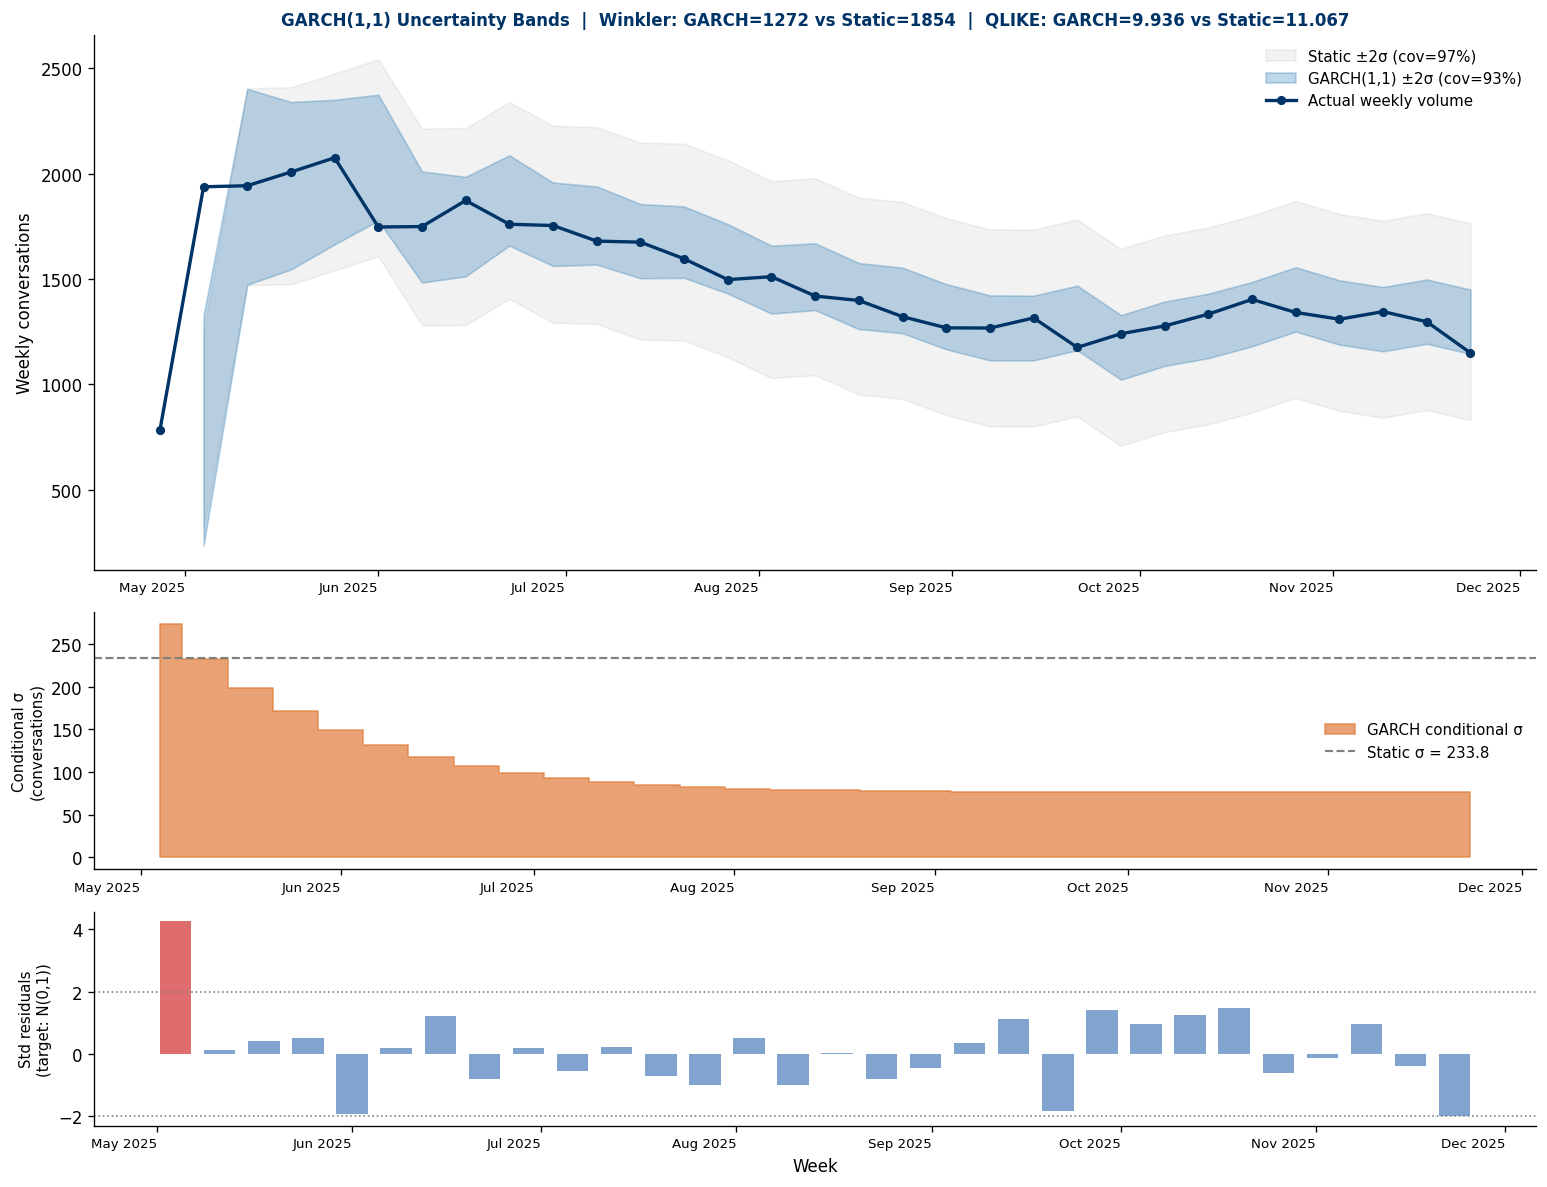

Saved: data/garch_diagnostics.png


In [16]:
try:
    from arch import arch_model as _arch_model
    ARCH_AVAILABLE = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'arch', '-q'], check=True)
    from arch import arch_model as _arch_model
    ARCH_AVAILABLE = True

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy import stats as sp_stats

if ARCH_AVAILABLE:
    ORANGE = '#E07B39'

    agg_vol  = weekly.set_index('week')['total'].sort_index().astype(float)
    diff_vol = agg_vol.diff().dropna()

    am  = _arch_model(diff_vol, vol='GARCH', p=1, q=1, mean='Constant', dist='normal')
    res = am.fit(disp='off')

    omega       = float(res.params['omega'])
    alpha       = float(res.params['alpha[1]'])
    beta        = float(res.params['beta[1]'])
    mu          = float(res.params.get('Const', 0))
    persistence = alpha + beta
    uncond_sig  = float(np.sqrt(omega / max(1 - persistence, 1e-6)))
    static_sig  = float(diff_vol.std())
    cond_vol    = res.conditional_volatility

    next_sig   = float(np.sqrt(res.forecast(horizon=1, reindex=False).variance.values[-1, 0]))
    last_level = float(agg_vol.iloc[-1])

    print('GARCH(1,1) — Aggregate Weekly Conversation Volume')
    print(f'  ω={omega:.3f}  α={alpha:.3f}  β={beta:.3f}')
    print(f'  Persistence (α+β) = {persistence:.3f}  '
          f'{"HIGH — shocks decay slowly (>0.85)" if persistence > 0.85 else "moderate"}')
    print(f'  Long-run σ = {uncond_sig:.1f}  |  Sample σ (IID) = {static_sig:.1f}')
    print(f'  AIC = {res.aic:.2f}  |  BIC = {res.bic:.2f}  |  Log-L = {res.loglikelihood:.2f}')

    std_resid = (res.resid / cond_vol).dropna()

    lb_r  = acorr_ljungbox(std_resid,    lags=[1, 4], return_df=True)
    lb_r2 = acorr_ljungbox(std_resid**2, lags=[1, 4], return_df=True)
    arch_lm_r, arch_p_r, _, _ = het_arch(std_resid.values, nlags=4)
    jb_stat, jb_p = sp_stats.jarque_bera(std_resid.values)[:2]

    print('\n Residual Diagnostics (pass = p > 0.05) ')
    print('  [Mean model]  LB on standardised residuals (no leftover autocorrelation):')
    for lag, row in lb_r.iterrows():
        ok = '✓' if row['lb_pvalue'] > 0.05 else '✗'
        print(f'    Lag {lag}: Q={row["lb_stat"]:.2f}  p={row["lb_pvalue"]:.3f}  {ok}')

    print('  [Variance model]  LB on squared std residuals (ARCH effects removed):')
    for lag, row in lb_r2.iterrows():
        ok = '✓' if row['lb_pvalue'] > 0.05 else '✗'
        print(f'    Lag {lag}: Q={row["lb_stat"]:.2f}  p={row["lb_pvalue"]:.3f}  {ok}')

    print(f'  [ARCH-LM on residuals]  LM={arch_lm_r:.3f}  p={arch_p_r:.3f}  '
          f'{"✓ no remaining ARCH" if arch_p_r > 0.05 else "✗ ARCH still present"}')
    print(f'  [Jarque-Bera normality]  JB={jb_stat:.2f}  p={jb_p:.3f}  '
          f'{"✓ residuals ~Normal" if jb_p > 0.05 else "✗ fat tails (consider t-dist)"}')

    if jb_p < 0.05:
        am_t  = _arch_model(diff_vol, vol='GARCH', p=1, q=1, mean='Constant', dist='t')
        res_t = am_t.fit(disp='off')
        print(f'  → Refitting with Student-t errors: AIC={res_t.aic:.2f} vs Normal AIC={res.aic:.2f}')
        if res_t.aic < res.aic:
            print('    Student-t preferred (lower AIC). Using t-dist fit for intervals below.')
            res = res_t
            cond_vol = res.conditional_volatility
            next_sig = float(np.sqrt(res.forecast(horizon=1, reindex=False).variance.values[-1, 0]))

    x_dates     = diff_vol.index
    y_actual    = agg_vol.values[1:]              # actual levels weeks 2…31
    level_fcast = agg_vol.values[:-1] + mu        # one-step-ahead mean in levels
    c_sigma     = cond_vol.values[:len(level_fcast)]
    upper_g     = level_fcast + 2 * c_sigma
    lower_g     = np.maximum(level_fcast - 2 * c_sigma, 0)
    upper_s     = level_fcast + 2 * static_sig
    lower_s     = np.maximum(level_fcast - 2 * static_sig, 0)

    def coverage(y, lo, hi):
        return np.mean((y >= lo) & (y <= hi))

    def winkler(y, lo, hi, alpha=0.05):
        """Winkler interval score. Width + penalty for misses. Lower = better."""
        width = hi - lo
        pen   = (2 / alpha) * (np.maximum(lo - y, 0) + np.maximum(y - hi, 0))
        return float(np.mean(width + pen))

    def qlike(y, sigma_sq):
        eps = 1e-8
        return float(np.mean(np.log(sigma_sq + eps) + (y**2) / (sigma_sq + eps)))

    diff_actual = np.diff(y_actual)  # level changes
    garch_var   = c_sigma[:-1]**2
    static_var  = np.full_like(garch_var, static_sig**2)

    cov_g  = coverage(y_actual, lower_g, upper_g)
    cov_s  = coverage(y_actual, lower_s, upper_s)
    wink_g = winkler(y_actual, lower_g, upper_g)
    wink_s = winkler(y_actual, lower_s, upper_s)
    qlike_g = qlike(diff_actual, garch_var)
    qlike_s = qlike(diff_actual, static_var)

    print('\n Interval Quality Metrics')
    print(f'  {"Metric":<30}  {"GARCH(1,1)":>12}  {"Static IID":>12}  {"Better":>8}')
    print('  ' + '-' * 68)
    print(f'  {"Coverage @ ±2σ (target 95%)":<30}  {cov_g*100:>11.1f}%  {cov_s*100:>11.1f}%  '
          f'{"→ GARCH" if abs(cov_g - 0.95) < abs(cov_s - 0.95) else "→ Static":>8}')
    print(f'  {"Winkler score (lower = better)":<30}  {wink_g:>12.1f}  {wink_s:>12.1f}  '
          f'{"→ GARCH" if wink_g < wink_s else "→ Static":>8}')
    print(f'  {"QLIKE loss (lower = better)":<30}  {qlike_g:>12.4f}  {qlike_s:>12.4f}  '
          f'{"→ GARCH" if qlike_g < qlike_s else "→ Static":>8}')
    print(f'\n  Next-week point forecast (= Naive):  {last_level + mu:.0f} conversations')
    print(f'  GARCH ±2σ:   [{max(last_level + mu - 2*next_sig, 0):.0f},  {last_level + mu + 2*next_sig:.0f}]  (width ±{2*next_sig:.0f})')
    print(f'  Static ±2σ:  [{max(last_level - 2*static_sig, 0):.0f},  {last_level + 2*static_sig:.0f}]  (width ±{2*static_sig:.0f})')

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False,
                              gridspec_kw={'height_ratios': [2.5, 1.2, 1]})

    ax1 = axes[0]
    ax1.fill_between(x_dates, lower_s, upper_s,
                     alpha=0.10, color='grey',    label=f'Static ±2σ (cov={cov_s*100:.0f}%)')
    ax1.fill_between(x_dates, lower_g, upper_g,
                     alpha=0.30, color='#2C7BB6', label=f'GARCH(1,1) ±2σ (cov={cov_g*100:.0f}%)')
    ax1.plot(agg_vol.index, agg_vol.values, 'o-', color=NAVY,
             lw=2.0, ms=4.5, label='Actual weekly volume', zorder=5)
    ax1.set_ylabel('Weekly conversations', fontsize=10)
    ax1.set_title(
        f'GARCH(1,1) Uncertainty Bands  |  '
        f'Winkler: GARCH={wink_g:.0f} vs Static={wink_s:.0f}  |  '
        f'QLIKE: GARCH={qlike_g:.3f} vs Static={qlike_s:.3f}',
        fontsize=10, fontweight='bold', color=NAVY)
    ax1.legend(frameon=False, fontsize=9, loc='upper right')
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax1.xaxis.get_majorticklabels(), ha='right', fontsize=8)
    ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.fill_between(x_dates, 0, c_sigma, step='mid', color=ORANGE, alpha=0.7,
                     label='GARCH conditional σ')
    ax2.axhline(static_sig, color='grey', ls='--', lw=1.3,
                label=f'Static σ = {static_sig:.1f}')
    ax2.set_ylabel('Conditional σ\n(conversations)', fontsize=9)
    ax2.legend(frameon=False, fontsize=9)
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax2.xaxis.get_majorticklabels(), ha='right', fontsize=8)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

    ax3 = axes[2]
    ax3.bar(std_resid.index, std_resid.values,
            color=np.where(np.abs(std_resid.values) > 2, '#d32f2f', '#4A7EBB'),
            alpha=0.7, width=pd.Timedelta(days=5))
    ax3.axhline(2,  color='grey', ls=':', lw=1)
    ax3.axhline(-2, color='grey', ls=':', lw=1)
    ax3.set_ylabel('Std residuals\n(target: N(0,1))', fontsize=9)
    ax3.set_xlabel('Week', fontsize=10)
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax3.xaxis.get_majorticklabels(), ha='right', fontsize=8)
    ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'garch_diagnostics.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: data/garch_diagnostics.png')
else:
    print('[SKIP] arch package not available')

## 4b. Post-spike sensitivity analysis

Drops weeks 1–5 (May 2025 launch surge) and re-runs CV on post-surge data to test whether the spike alone prevents parametric models from beating naive.

In [17]:
SPIKE_END_WEEKS = 5 

print(f'SENSITIVITY: Post-spike CV (excluding first {SPIKE_END_WEEKS} weeks — May 2025 surge)')
remaining = 31 - SPIKE_END_WEEKS
print(f'Remaining: {remaining} weeks  |  min_train={MIN_TRAIN}  |  folds per cluster ≈ {remaining - MIN_TRAIN}')

ps_rows = []
for cid in top_clusters:
    s = (df_ct[df_ct.cluster_id == cid][['week', 'chunk_count']]
         .rename(columns={'week': 'ds', 'chunk_count': 'y'})
         .sort_values('ds').reset_index(drop=True))
    s['ds'] = pd.to_datetime(s['ds'])
    s_ps = s.iloc[SPIKE_END_WEEKS:].reset_index(drop=True)

    if len(s_ps) < MIN_TRAIN + 1:
        print(f'C{cid:2d}: only {len(s_ps)} post-spike weeks — skip')
        continue

    folds = []
    for split in range(MIN_TRAIN, len(s_ps)):
        train_ps  = s_ps.iloc[:split]
        actual_val = s_ps.iloc[split]['y']
        e_pred = ets_predict_one(train_ps['y'].values)
        s_pred = sarima_predict_one(train_ps['y'].values)
        p_pred = np.nan
        try:
            _mp = Prophet(weekly_seasonality=False, daily_seasonality=False,
                          yearly_seasonality=False, changepoint_prior_scale=0.1)
            _mp.fit(train_ps.copy())
            _fu = _mp.make_future_dataframe(periods=1, freq='7D')
            p_pred = max(_mp.predict(_fu)['yhat'].iloc[-1], 0)
        except Exception:
            pass
        n_last = float(train_ps['y'].iloc[-1])
        folds.append({'actual': actual_val, 'ets': e_pred, 'sarima': s_pred,
                      'prophet': p_pred, 'naive_last': n_last})

    fdf = pd.DataFrame(folds)
    a  = fdf['actual'].values
    nl = fdf['naive_last'].values

    valid_e = ~np.isnan(fdf['ets'].values)
    valid_s = ~np.isnan(fdf['sarima'].values)
    valid_p = ~np.isnan(fdf['prophet'].values)

    mae_e  = mean_absolute_error(a[valid_e], fdf['ets'].values[valid_e]) if valid_e.sum() > 0 else np.nan
    mae_s  = mean_absolute_error(a[valid_s], fdf['sarima'].values[valid_s]) if valid_s.sum() > 0 else np.nan
    mae_p  = mean_absolute_error(a[valid_p], fdf['prophet'].values[valid_p]) if valid_p.sum() > 0 else np.nan
    mae_nl = mean_absolute_error(a, nl)

    dm_p_e = diebold_mariano(a[valid_e], fdf['ets'].values[valid_e], nl[valid_e])[1] if valid_e.sum() >= 3 else np.nan
    dm_p_s = diebold_mariano(a[valid_s], fdf['sarima'].values[valid_s], nl[valid_s])[1] if valid_s.sum() >= 3 else np.nan
    dm_p_p = diebold_mariano(a[valid_p], fdf['prophet'].values[valid_p], nl[valid_p])[1] if valid_p.sum() >= 3 else np.nan

    beat_e = (not np.isnan(mae_e)) and (mae_e < mae_nl)
    beat_s = (not np.isnan(mae_s)) and (mae_s < mae_nl)
    beat_p = (not np.isnan(mae_p)) and (mae_p < mae_nl)
    flag   = ' ◀ BEATS NAIVE' if (beat_e or beat_s or beat_p) else ''

    print(f'C{cid:2d} ({len(folds)} folds)  '
          f'P={mae_p:.2f}{"✓" if beat_p else " "}  '
          f'ETS={mae_e:.2f}{"✓" if beat_e else " "}  '
          f'SARIMA={mae_s:.2f}{"✓" if beat_s else " "}  '
          f'Naive={mae_nl:.2f}  '
          f'DM p: P={dm_p_p:.3f}  E={dm_p_e:.3f}  S={dm_p_s:.3f}{flag}')

    ps_rows.append({
        'cluster_id':        cid,
        'n_weeks_ps':        len(s_ps),
        'cv_folds_ps':       len(folds),
        'prophet_mae_ps':    round(mae_p, 2),
        'ets_mae_ps':        round(mae_e, 2),
        'sarima_mae_ps':     round(mae_s, 2),
        'naive_mae_ps':      round(mae_nl, 2),
        'prophet_beats_naive': beat_p,
        'ets_beats_naive':   beat_e,
        'sarima_beats_naive': beat_s,
        'dm_p_prophet':      round(dm_p_p, 4) if not np.isnan(dm_p_p) else np.nan,
        'dm_p_ets':          round(dm_p_e, 4) if not np.isnan(dm_p_e) else np.nan,
        'dm_p_sarima':       round(dm_p_s, 4) if not np.isnan(dm_p_s) else np.nan,
    })

ps_df = pd.DataFrame(ps_rows)
if not ps_df.empty:
    ps_df.to_csv(RESULTS_DIR / 'forecasting_postspike_sensitivity.csv', index=False)
    n_prop_beat = int(ps_df['prophet_beats_naive'].sum())
    n_ets_beat = int(ps_df['ets_beats_naive'].sum())
    n_sar_beat = int(ps_df['sarima_beats_naive'].sum())
    total = len(ps_df)
    print(f'\nPost-spike: Prophet beats naive {n_prop_beat}/{total} | '
          f'ETS beats naive {n_ets_beat}/{total} | SARIMA beats naive {n_sar_beat}/{total} clusters')
    if n_prop_beat + n_ets_beat + n_sar_beat > 0:
        winners = ps_df[ps_df['prophet_beats_naive'] | ps_df['ets_beats_naive'] | ps_df['sarima_beats_naive']]
        for _, wr in winners.iterrows():
            cand = []
            if wr['prophet_beats_naive']:
                cand.append(('Prophet', wr['prophet_mae_ps']))
            if wr['ets_beats_naive']:
                cand.append(('ETS', wr['ets_mae_ps']))
            if wr['sarima_beats_naive']:
                cand.append(('SARIMA', wr['sarima_mae_ps']))
            best_model, best_mae = min(cand, key=lambda x: x[1])
            reduction  = (wr['naive_mae_ps'] - best_mae) / wr['naive_mae_ps'] * 100
            print(f'  C{int(wr["cluster_id"]):2d}: {best_model} MAE={best_mae:.2f} < Naive={wr["naive_mae_ps"]:.2f} '
                  f'({reduction:.1f}% improvement)')
        print('\n  → Launch spike (not model inadequacy) is the primary obstacle.')
        print('  → With 12+ months of post-stabilisation data, parametric models are viable.')
    else:
        print('  → Parametric models still lose to naive on post-spike data.')
        print('  → Ongoing volume decline — not spike alone — drives naive dominance.')
    print('Saved: data/forecasting_postspike_sensitivity.csv')

SENSITIVITY: Post-spike CV (excluding first 5 weeks — May 2025 surge)
Remaining: 26 weeks  |  min_train=8  |  folds per cluster ≈ 18


00:23:50 - cmdstanpy - INFO - Chain [1] start processing
00:23:50 - cmdstanpy - INFO - Chain [1] done processing
00:23:51 - cmdstanpy - INFO - Chain [1] start processing
00:23:51 - cmdstanpy - INFO - Chain [1] done processing
00:23:51 - cmdstanpy - INFO - Chain [1] start processing
00:23:52 - cmdstanpy - INFO - Chain [1] done processing
00:23:52 - cmdstanpy - INFO - Chain [1] start processing
00:23:52 - cmdstanpy - INFO - Chain [1] done processing
00:23:53 - cmdstanpy - INFO - Chain [1] start processing
00:23:53 - cmdstanpy - INFO - Chain [1] done processing
00:23:53 - cmdstanpy - INFO - Chain [1] start processing
00:23:53 - cmdstanpy - INFO - Chain [1] done processing
00:23:54 - cmdstanpy - INFO - Chain [1] start processing
00:23:54 - cmdstanpy - INFO - Chain [1] done processing
00:23:54 - cmdstanpy - INFO - Chain [1] start processing
00:23:54 - cmdstanpy - INFO - Chain [1] done processing
00:23:55 - cmdstanpy - INFO - Chain [1] start processing
00:23:55 - cmdstanpy - INFO - Chain [1]

C11 (18 folds)  P=57.79   ETS=53.20   SARIMA=60.30   Naive=43.17  DM p: P=0.235  E=0.269  S=0.204


00:24:06 - cmdstanpy - INFO - Chain [1] start processing
00:24:06 - cmdstanpy - INFO - Chain [1] done processing
00:24:07 - cmdstanpy - INFO - Chain [1] start processing
00:24:07 - cmdstanpy - INFO - Chain [1] done processing
00:24:08 - cmdstanpy - INFO - Chain [1] start processing
00:24:08 - cmdstanpy - INFO - Chain [1] done processing
00:24:09 - cmdstanpy - INFO - Chain [1] start processing
00:24:09 - cmdstanpy - INFO - Chain [1] done processing
00:24:10 - cmdstanpy - INFO - Chain [1] start processing
00:24:10 - cmdstanpy - INFO - Chain [1] done processing
00:24:11 - cmdstanpy - INFO - Chain [1] start processing
00:24:11 - cmdstanpy - INFO - Chain [1] done processing
00:24:12 - cmdstanpy - INFO - Chain [1] start processing
00:24:12 - cmdstanpy - INFO - Chain [1] done processing
00:24:12 - cmdstanpy - INFO - Chain [1] start processing
00:24:12 - cmdstanpy - INFO - Chain [1] done processing
00:24:12 - cmdstanpy - INFO - Chain [1] start processing
00:24:12 - cmdstanpy - INFO - Chain [1]

C 8 (18 folds)  P=37.78   ETS=32.06   SARIMA=34.15   Naive=29.00  DM p: P=0.050  E=0.102  S=0.150


...

C16 (18 folds)  P=37.49✓  ETS=40.32✓  SARIMA=41.57✓  Naive=45.28  DM p: P=0.833  E=0.848  S=0.549 ◀ BEATS NAIVE


00:24:44 - cmdstanpy - INFO - Chain [1] start processing
00:24:44 - cmdstanpy - INFO - Chain [1] done processing
00:24:44 - cmdstanpy - INFO - Chain [1] start processing
00:24:44 - cmdstanpy - INFO - Chain [1] done processing
00:24:45 - cmdstanpy - INFO - Chain [1] start processing
00:24:45 - cmdstanpy - INFO - Chain [1] done processing
00:24:45 - cmdstanpy - INFO - Chain [1] start processing
00:24:45 - cmdstanpy - INFO - Chain [1] done processing
00:24:45 - cmdstanpy - INFO - Chain [1] start processing
00:24:46 - cmdstanpy - INFO - Chain [1] done processing
00:24:46 - cmdstanpy - INFO - Chain [1] start processing
00:24:46 - cmdstanpy - INFO - Chain [1] done processing
00:24:47 - cmdstanpy - INFO - Chain [1] start processing
00:24:47 - cmdstanpy - INFO - Chain [1] done processing
00:24:48 - cmdstanpy - INFO - Chain [1] start processing
00:24:48 - cmdstanpy - INFO - Chain [1] done processing
00:24:48 - cmdstanpy - INFO - Chain [1] start processing
00:24:48 - cmdstanpy - INFO - Chain [1]

C13 (18 folds)  P=33.74✓  ETS=37.21✓  SARIMA=42.78✓  Naive=46.00  DM p: P=0.214  E=0.327  S=0.853 ◀ BEATS NAIVE


00:24:53 - cmdstanpy - INFO - Chain [1] start processing
00:24:53 - cmdstanpy - INFO - Chain [1] done processing
00:24:53 - cmdstanpy - INFO - Chain [1] start processing
00:24:53 - cmdstanpy - INFO - Chain [1] done processing
00:24:54 - cmdstanpy - INFO - Chain [1] start processing
00:24:54 - cmdstanpy - INFO - Chain [1] done processing
00:24:54 - cmdstanpy - INFO - Chain [1] start processing
00:24:54 - cmdstanpy - INFO - Chain [1] done processing
00:24:55 - cmdstanpy - INFO - Chain [1] start processing
00:24:55 - cmdstanpy - INFO - Chain [1] done processing
00:24:56 - cmdstanpy - INFO - Chain [1] start processing
00:24:56 - cmdstanpy - INFO - Chain [1] done processing
00:24:57 - cmdstanpy - INFO - Chain [1] start processing
00:24:57 - cmdstanpy - INFO - Chain [1] done processing
00:24:58 - cmdstanpy - INFO - Chain [1] start processing
00:24:58 - cmdstanpy - INFO - Chain [1] done processing
00:24:58 - cmdstanpy - INFO - Chain [1] start processing
00:24:58 - cmdstanpy - INFO - Chain [1]

C15 (18 folds)  P=29.64✓  ETS=29.68✓  SARIMA=35.74   Naive=30.83  DM p: P=0.902  E=0.866  S=0.384 ◀ BEATS NAIVE

Post-spike: Prophet beats naive 3/6 | ETS beats naive 3/6 | SARIMA beats naive 2/6 clusters
  C16: Prophet MAE=37.49 < Naive=45.28 (17.2% improvement)
  C13: Prophet MAE=33.74 < Naive=46.00 (26.7% improvement)
  C15: Prophet MAE=29.64 < Naive=30.83 (3.9% improvement)

  → Launch spike (not model inadequacy) is the primary obstacle.
  → With 12+ months of post-stabilisation data, parametric models are viable.
Saved: data/forecasting_postspike_sensitivity.csv


00:25:24 - cmdstanpy - INFO - Chain [1] start processing
00:25:24 - cmdstanpy - INFO - Chain [1] done processing


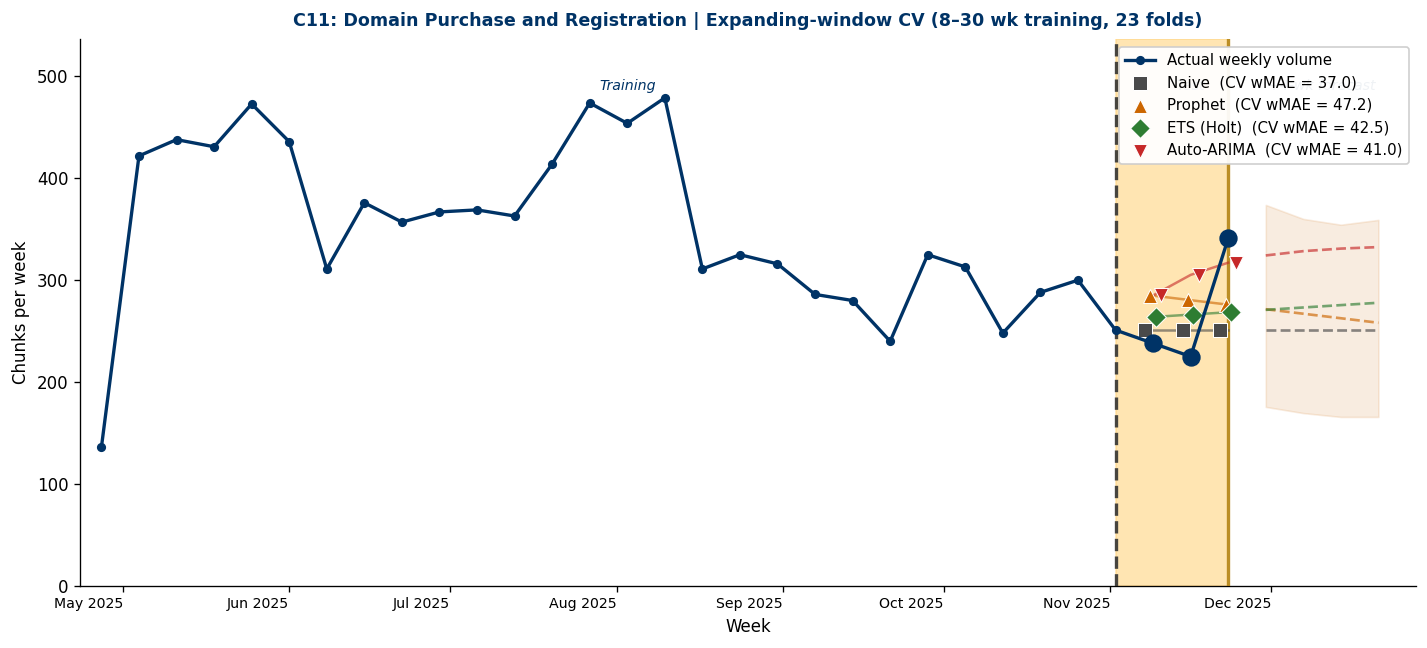

Saved: data/forecast_model_comparison_plot.png
Hold-out MAE (chunks) -- Naive:43.0  Prophet:55.7  ETS:46.5  ARIMA:50.3


In [18]:
if model_comp_df.empty:
    print('[SKIP] No results to plot.')
else:
    cid_plot = int(model_comp_df.sort_values('n_weeks', ascending=False).iloc[0]['cluster_id'])
    _title   = titles_dict.get(cid_plot, f'Cluster {cid_plot}')

    s = (df_ct[df_ct.cluster_id == cid_plot][['week', 'chunk_count']]
         .rename(columns={'week': 'ds', 'chunk_count': 'y'})
         .sort_values('ds').reset_index(drop=True))
    s['ds'] = pd.to_datetime(s['ds'])
    train = s.iloc[:-HOLDOUT].copy()
    test  = s.iloc[-HOLDOUT:].copy()
    actual_vals = test['y'].values
    future_dates = pd.date_range(
        s['ds'].iloc[-1] + pd.Timedelta(weeks=1), periods=FWD, freq='7D')

    m_p = Prophet(weekly_seasonality=False, daily_seasonality=False,
                  yearly_seasonality=False, changepoint_prior_scale=0.1,
                  interval_width=0.80)
    m_p.fit(train)
    fut_frame = m_p.make_future_dataframe(periods=HOLDOUT + FWD, freq='7D')
    fcst_p    = m_p.predict(fut_frame)
    prophet_test = np.maximum(fcst_p['yhat'].values[-(HOLDOUT + FWD):-FWD], 0)
    prophet_fut  = np.maximum(fcst_p['yhat'].values[-FWD:], 0)
    prophet_fut_lo = np.maximum(fcst_p['yhat_lower'].values[-FWD:], 0)
    prophet_fut_hi = fcst_p['yhat_upper'].values[-FWD:]

    ets_ok = False
    test_ets = future_ets = np.full(max(HOLDOUT, FWD), np.nan)
    try:
        ets_fit = ExponentialSmoothing(
            train['y'].values.astype(float), trend='add', seasonal=None,
            initialization_method='estimated').fit(optimized=True, use_brute=True)
        _ets_full = np.maximum(ets_fit.forecast(HOLDOUT + FWD), 0)
        test_ets  = _ets_full[:HOLDOUT]
        future_ets = _ets_full[HOLDOUT:]
        ets_ok = True
    except Exception:
        pass

    sarima_ok = False
    test_sarima = future_sarima = np.full(max(HOLDOUT, FWD), np.nan)
    if PMDARIMA_AVAILABLE:
        try:
            from pmdarima import auto_arima as _auto_arima
            arima_m = _auto_arima(
                train['y'].values.astype(float), start_p=0, max_p=3,
                start_q=0, max_q=3, d=None, seasonal=False,
                information_criterion='aic', error_action='ignore',
                suppress_warnings=True)
            _sar_full     = np.maximum(arima_m.predict(HOLDOUT + FWD), 0)
            test_sarima   = _sar_full[:HOLDOUT]
            future_sarima = _sar_full[HOLDOUT:]
            sarima_ok = True
        except Exception:
            pass

    naive_val    = float(train['y'].iloc[-1])
    test_naive   = np.full(HOLDOUT, naive_val)
    future_naive = np.full(FWD, naive_val)

    from sklearn.metrics import mean_absolute_error as _mae
    ho_mae = {
        'Naive':      _mae(actual_vals, test_naive),
        'Prophet':    _mae(actual_vals, prophet_test),
        'ETS':        _mae(actual_vals, test_ets[:HOLDOUT]) if ets_ok else np.nan,
        'Auto-ARIMA': _mae(actual_vals, test_sarima[:HOLDOUT]) if sarima_ok else np.nan,
    }

    _cvol = (df_ct[df_ct['cluster_id'].isin(top_clusters)]
             .groupby('cluster_id')['chunk_count'].sum())
    _vs   = (_cvol / _cvol.sum()).to_dict()
    _mc_w = model_comp_df.copy()
    _mc_w['vol_share'] = _mc_w['cluster_id'].map(_vs).fillna(0)

    def _wmae(col):
        if col not in _mc_w.columns: return np.nan
        v = _mc_w[col].notna()
        d = _mc_w.loc[v, 'vol_share'].sum()
        return (_mc_w.loc[v, col] * _mc_w.loc[v, 'vol_share']).sum() / d if d > 0 else np.nan

    wmae_cv = {
        'Naive':       _wmae('naive_last_mae'),
        'ETS':         _wmae('ets_mae'),
        'Auto-ARIMA':  _wmae('sarima_mae'),
        'Prophet':     _wmae('prophet_mae'),
    }

    fig, ax_ts = plt.subplots(figsize=(12, 5.5))

    train_end = train['ds'].iloc[-1]
    test_ds   = test['ds'].reset_index(drop=True)
    fut_ds    = pd.Series(pd.to_datetime(future_dates))
    x_start   = s['ds'].iloc[0] - pd.Timedelta(days=4)
    x_end     = fut_ds.iloc[-1] + pd.Timedelta(days=7)

    ax_ts.axvspan(x_start,   train_end,         color='white',   alpha=1.0, zorder=0)
    ax_ts.axvspan(train_end, test_ds.iloc[-1],  color='#FFD580', alpha=0.60, zorder=0)
    ax_ts.axvspan(test_ds.iloc[-1], x_end,      color='white',   alpha=1.0, zorder=0)

    ax_ts.axvline(train_end,        color='#333', ls='--', lw=2.0, alpha=0.9, zorder=5)
    ax_ts.axvline(test_ds.iloc[-1], color='#B07A00', ls='-', lw=2.0, alpha=0.85, zorder=5)

    y_hi = s['y'].max()
    for xpos, label, col in [
        (train['ds'].iloc[len(train)//2], 'Training', NAVY),
        (test_ds.mean(),                  'Test',             NAVY),
        (fut_ds.mean(),                   f'+{FWD}-wk forecast', NAVY),
    ]:
        ax_ts.text(xpos, y_hi * 1.01, label, ha='center', fontsize=8.5,
                   color=col, style='italic', va='bottom')

    ax_ts.plot(s['ds'], s['y'], 'o-', color=NAVY, lw=2.0, ms=4.5, zorder=8,
               label='Actual weekly volume')
    ax_ts.plot(test_ds, actual_vals, 'o', color=NAVY, ms=10, zorder=9,
               label='_nolegend_')

    _offsets = {'naive': -1.5, 'prophet': -0.5, 'ets': 0.5, 'sarima': 1.5}

    _models = [
        ('naive',   'Naive',       NAIVE_C,   's', test_naive,            future_naive,          True),
        ('prophet', 'Prophet',     PROPHET_C, '^', prophet_test,          prophet_fut,           True),
        ('ets',     'ETS (Holt)',  ETS_C,     'D', test_ets[:HOLDOUT],    future_ets[:FWD],      ets_ok),
        ('sarima',  'Auto-ARIMA', SARIMA_C,  'v', test_sarima[:HOLDOUT], future_sarima[:FWD],   sarima_ok),
    ]
    for key, name, col, mk, test_vals, fut_vals, ok in _models:
        if not ok: continue
        wm = wmae_cv.get(name.split()[0] if ' ' in name else name, np.nan)
        if np.isnan(wm): wm = wmae_cv.get(name, np.nan)
        wm_str = f'{wm:.1f}' if not np.isnan(wm) else 'n/a'
        jx = test_ds + pd.Timedelta(days=_offsets[key])
        ax_ts.scatter(jx, test_vals, marker=mk, color=col, s=70, zorder=7,
                      edgecolors='white', linewidths=0.6,
                      label=f'{name}  (CV wMAE = {wm_str})')
        ax_ts.plot(test_ds, test_vals, '-', color=col, lw=1.5, alpha=0.6, zorder=6,
                   label='_nolegend_')
        ax_ts.plot(fut_ds, fut_vals, '--', color=col, lw=1.6, alpha=0.65,
                   zorder=6, label='_nolegend_')

    ax_ts.fill_between(fut_ds, prophet_fut_lo, prophet_fut_hi,
                       alpha=0.12, color=PROPHET_C, label='_nolegend_')

    ax_ts.set_xlim(x_start, x_end)
    ax_ts.set_ylim(0, y_hi * 1.12)
    ax_ts.set_xlabel('Week', fontsize=10)
    ax_ts.set_ylabel('Chunks per week', fontsize=10)
    _ts_title = (f'C{cid_plot}: {_title} | '
                f'Expanding-window CV ({MIN_TRAIN}–{len(s)-1} wk training, {len(s)-MIN_TRAIN} folds)')
    ax_ts.set_title(_ts_title, fontsize=10.5, fontweight='bold', color=NAVY, pad=8)
    ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax_ts.xaxis.get_majorticklabels(), ha='right', fontsize=8.5)
    ax_ts.legend(fontsize=9, loc='upper right', framealpha=0.94,
                 edgecolor='#cccccc', frameon=True)
    sns.despine(ax=ax_ts)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'forecast_model_comparison_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: data/forecast_model_comparison_plot.png')
    print(f'Hold-out MAE (chunks) -- Naive:{ho_mae["Naive"]:.1f}  Prophet:{ho_mae["Prophet"]:.1f}  '
          f'ETS:{ho_mae["ETS"]:.1f}  ARIMA:{ho_mae["Auto-ARIMA"]:.1f}')

## 6. Model win-rate summary

(Weighted MAE = sum of cluster_MAE x cluster_chunk_share)
  Model                 Weighted MAE  Unweighted MAE
  ----------------------------------------------------
  Naive (last)                 37.02           37.29
  Auto-ARIMA                   41.02           41.04  (loses to naive)
  ETS (Holt)                   42.53           42.19  (loses to naive)
  Prophet                      47.20           46.51  (loses to naive)

  Cluster volume shares:
    C11 (Domain Purchase and Registration): 19.6%
    C 8 (Human Agent Escalation Requests): 18.8%
    C20 (Website Down HTTP Error Diagnosis): 16.2%
    C16 (AI Builder Site Generation Editing): 16.1%
    C13 (Account and WordPress Login): 14.7%
    C15 (AI Builder Layout and Styling): 14.6%


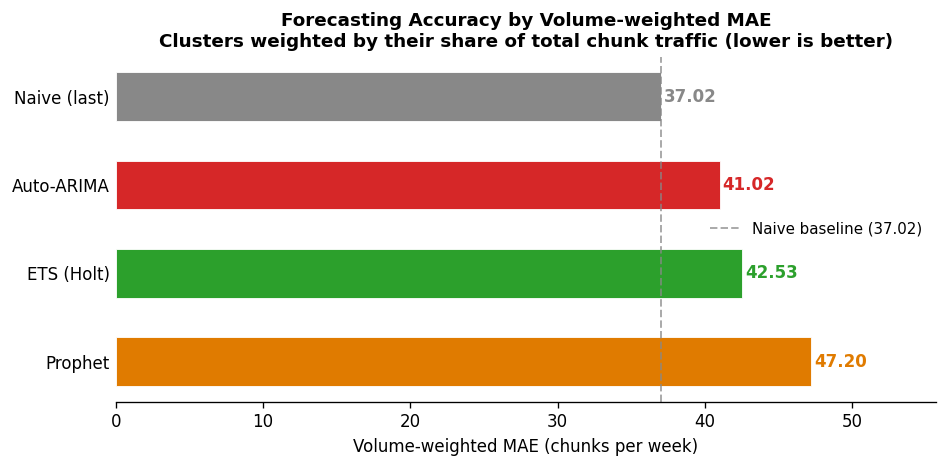

Saved: data/forecast_wmae_comparison.png


In [19]:
if not model_comp_df.empty:
    cluster_vol = (df_ct[df_ct['cluster_id'].isin(top_clusters)]
                   .groupby('cluster_id')['chunk_count'].sum()
                   .reset_index(name='chunk_count'))
    total_chunks = cluster_vol['chunk_count'].sum()
    cluster_vol['vol_share'] = cluster_vol['chunk_count'] / total_chunks

    mc_w = model_comp_df.merge(cluster_vol[['cluster_id', 'vol_share']], on='cluster_id', how='left')
    mc_w['vol_share'] = mc_w['vol_share'].fillna(0)

    model_specs = [
        ('Prophet',        'prophet_mae',     '#E07B00'),
        ('ETS (Holt)',     'ets_mae',         '#2ca02c'),
        ('Auto-ARIMA',     'sarima_mae',      '#d62728'),
        ('Naive (last)',   'naive_last_mae',  '#888888'),
    ]

    wmae_rows = []
    for label, col, color in model_specs:
        if col not in mc_w.columns:
            continue
        valid  = mc_w[col].notna()
        w_denom = mc_w.loc[valid, 'vol_share'].sum()
        wmae   = (mc_w.loc[valid, col] * mc_w.loc[valid, 'vol_share']).sum() / w_denom if w_denom > 0 else np.nan
        umae   = mc_w.loc[valid, col].mean()
        wmae_rows.append({'label': label, 'col': col, 'color': color,
                          'wmae': wmae, 'umae': umae})

    wmae_df = pd.DataFrame(wmae_rows).sort_values('wmae')

    print('(Weighted MAE = sum of cluster_MAE x cluster_chunk_share)')
    print(f'  {"Model":20s}  {"Weighted MAE":>12}  {"Unweighted MAE":>14}')
    print('  ' + '-' * 52)
    naive_wmae = wmae_df[wmae_df['label'].str.startswith('Naive')]['wmae'].values[0] \
                 if any(wmae_df['label'].str.startswith('Naive')) else float('inf')
    for _, row in wmae_df.iterrows():
        note = '' if 'Naive' in row['label'] else \
               ('  (beats naive)' if row['wmae'] < naive_wmae else '  (loses to naive)')
        print(f"  {row['label']:20s}  {row['wmae']:>12.2f}  {row['umae']:>14.2f}{note}")

    print('\n  Cluster volume shares:')
    for _, r in cluster_vol.sort_values('vol_share', ascending=False).iterrows():
        _t = titles_dict.get(int(r['cluster_id']), f"C{int(r['cluster_id'])}")[:35]
        print(f"    C{int(r['cluster_id']):2d} ({_t}): {r['vol_share']*100:.1f}%")

    fig, ax = plt.subplots(figsize=(8, 4))

    wmae_plot = wmae_df.iloc[::-1].reset_index(drop=True)  # reverse so best is at top
    bars = ax.barh(wmae_plot['label'], wmae_plot['wmae'],
                   color=wmae_plot['color'], height=0.55, edgecolor='white', linewidth=0.5)

    naive_val = wmae_df[wmae_df['label'].str.startswith('Naive')]['wmae'].values
    if len(naive_val):
        ax.axvline(naive_val[0], color='#888888', ls='--', lw=1.2, alpha=0.7,
                   label=f'Naive baseline ({naive_val[0]:.2f})')
        ax.legend(fontsize=9, frameon=False)

    for bar, (_, row) in zip(bars, wmae_plot.iterrows()):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{row["wmae"]:.2f}', va='center', fontsize=10, fontweight='bold',
                color=row['color'])

    ax.set_xlabel('Volume-weighted MAE (chunks per week)', fontsize=10)
    ax.set_title(
        'Forecasting Accuracy by Volume-weighted MAE\n'
        'Clusters weighted by their share of total chunk traffic (lower is better)',
        fontsize=11, fontweight='bold')
    ax.set_xlim(0, wmae_df['wmae'].max() * 1.18)
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis='y', length=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'forecast_wmae_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: data/forecast_wmae_comparison.png')

## 7. Forecast plots for top 3 clusters

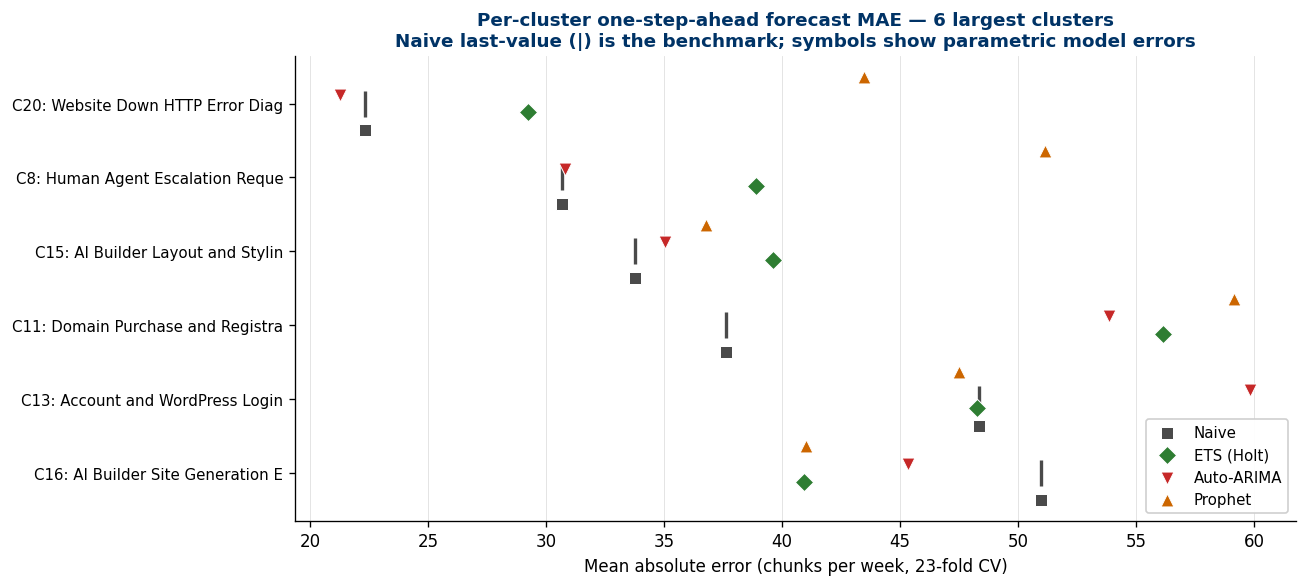

Saved: data/forecast_per_cluster_mae.png


In [20]:
if model_comp_df.empty:
    print('[SKIP] No results to plot.')
else:
    _cvol = (df_ct[df_ct['cluster_id'].isin(top_clusters)]
             .groupby('cluster_id')['chunk_count'].sum())
    _vs   = (_cvol / _cvol.sum()).to_dict()
    _mc   = model_comp_df.copy()
    _mc['vol_share'] = _mc['cluster_id'].map(_vs).fillna(0)

    model_specs = [
        ('Naive',       'naive_last_mae', NAIVE_C,   's'),
        ('ETS (Holt)',  'ets_mae',        ETS_C,     'D'),
        ('Auto-ARIMA',  'sarima_mae',     SARIMA_C,  'v'),
        ('Prophet',     'prophet_mae',    PROPHET_C, '^'),
    ]

    cluster_labels = {cid: f"C{cid}: {titles_dict.get(cid, f'Cluster {cid}')[:28]}"
                      for cid in top_clusters}

    fig, ax = plt.subplots(figsize=(11, 5))

    cluster_order = (model_comp_df.groupby('cluster_id')['naive_last_mae']
                     .mean().sort_values(ascending=False).index.tolist())
    y_ticks = {cid: i for i, cid in enumerate(cluster_order)}
    n_models = len(model_specs)
    offsets = np.linspace(-(n_models - 1) * 0.12, (n_models - 1) * 0.12, n_models)

    for (lbl, col, color, mk), off in zip(model_specs, offsets):
        if col not in _mc.columns:
            continue
        vals = _mc.set_index('cluster_id')[col]
        xs = [vals.get(cid, np.nan) for cid in cluster_order]
        ys = [y_ticks[cid] + off for cid in cluster_order]
        ax.scatter(xs, ys, marker=mk, color=color, s=60, zorder=5,
                   edgecolors='white', linewidths=0.6, label=lbl)

    naive_vals = _mc.set_index('cluster_id').get('naive_last_mae', pd.Series())
    for cid in cluster_order:
        nv = naive_vals.get(cid, np.nan)
        if not np.isnan(nv):
            ax.plot([nv], [y_ticks[cid]], '|', color=NAIVE_C,
                    ms=16, mew=2.0, zorder=4, label='_nolegend_')

    ax.set_yticks(list(y_ticks.values()))
    ax.set_yticklabels([cluster_labels[c] for c in cluster_order], fontsize=9)
    ax.set_xlabel('Mean absolute error (chunks per week, 23-fold CV)', fontsize=10)
    ax.set_title(
        'Per-cluster one-step-ahead forecast MAE — 6 largest clusters\n'
        'Naive last-value (|) is the benchmark; symbols show parametric model errors',
        fontsize=11, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9, loc='lower right', framealpha=0.93, edgecolor='#cccccc')
    ax.grid(axis='x', lw=0.5, alpha=0.4)
    sns.despine(ax=ax, left=False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'forecast_per_cluster_mae.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: data/forecast_per_cluster_mae.png')

## Daily forecasting

Expanding-window CV on daily conversation counts (from `df` already in memory).  
Target: conversations/day per cluster. Holdout = 14 days, stride = 14 days, min_train = 56 days.  
Models: Naive (last day), Prophet (weekly seasonality), ETS (Holt-Winters, period=7).

00:27:13 - cmdstanpy - INFO - Chain [1] start processing
00:27:13 - cmdstanpy - INFO - Chain [1] done processing


Daily range: 2025-05-01 to 2025-11-29  (213 days)
CV: min_train=56d  holdout=14d  stride=14d
C11 (Domain Purchase and Registration): 11 folds


00:27:14 - cmdstanpy - INFO - Chain [1] start processing
00:27:14 - cmdstanpy - INFO - Chain [1] done processing
00:27:14 - cmdstanpy - INFO - Chain [1] start processing
00:27:14 - cmdstanpy - INFO - Chain [1] done processing
00:27:14 - cmdstanpy - INFO - Chain [1] start processing
00:27:15 - cmdstanpy - INFO - Chain [1] done processing
00:27:15 - cmdstanpy - INFO - Chain [1] start processing
00:27:15 - cmdstanpy - INFO - Chain [1] done processing
00:27:15 - cmdstanpy - INFO - Chain [1] start processing
00:27:15 - cmdstanpy - INFO - Chain [1] done processing
00:27:15 - cmdstanpy - INFO - Chain [1] start processing
00:27:15 - cmdstanpy - INFO - Chain [1] done processing
00:27:15 - cmdstanpy - INFO - Chain [1] start processing
00:27:15 - cmdstanpy - INFO - Chain [1] done processing
00:27:16 - cmdstanpy - INFO - Chain [1] start processing
00:27:16 - cmdstanpy - INFO - Chain [1] done processing
00:27:16 - cmdstanpy - INFO - Chain [1] start processing
00:27:16 - cmdstanpy - INFO - Chain [1]

C8 (Human Agent Escalation Requests): 11 folds


00:27:17 - cmdstanpy - INFO - Chain [1] done processing
00:27:17 - cmdstanpy - INFO - Chain [1] start processing
00:27:17 - cmdstanpy - INFO - Chain [1] done processing
00:27:17 - cmdstanpy - INFO - Chain [1] start processing
00:27:17 - cmdstanpy - INFO - Chain [1] done processing
00:27:17 - cmdstanpy - INFO - Chain [1] start processing
00:27:18 - cmdstanpy - INFO - Chain [1] done processing
00:27:18 - cmdstanpy - INFO - Chain [1] start processing
00:27:18 - cmdstanpy - INFO - Chain [1] done processing
00:27:18 - cmdstanpy - INFO - Chain [1] start processing
00:27:18 - cmdstanpy - INFO - Chain [1] done processing
00:27:18 - cmdstanpy - INFO - Chain [1] start processing
00:27:18 - cmdstanpy - INFO - Chain [1] done processing
00:27:19 - cmdstanpy - INFO - Chain [1] start processing
00:27:19 - cmdstanpy - INFO - Chain [1] done processing
00:27:19 - cmdstanpy - INFO - Chain [1] start processing
00:27:19 - cmdstanpy - INFO - Chain [1] done processing
00:27:19 - cmdstanpy - INFO - Chain [1] 

...

C13 (Account and WordPress Login): 11 folds


00:27:26 - cmdstanpy - INFO - Chain [1] done processing
00:27:26 - cmdstanpy - INFO - Chain [1] start processing
00:27:26 - cmdstanpy - INFO - Chain [1] done processing
00:27:27 - cmdstanpy - INFO - Chain [1] start processing
00:27:27 - cmdstanpy - INFO - Chain [1] done processing
00:27:27 - cmdstanpy - INFO - Chain [1] start processing
00:27:27 - cmdstanpy - INFO - Chain [1] done processing
00:27:28 - cmdstanpy - INFO - Chain [1] start processing
00:27:28 - cmdstanpy - INFO - Chain [1] done processing
00:27:28 - cmdstanpy - INFO - Chain [1] start processing
00:27:28 - cmdstanpy - INFO - Chain [1] done processing
00:27:28 - cmdstanpy - INFO - Chain [1] start processing
00:27:28 - cmdstanpy - INFO - Chain [1] done processing
00:27:28 - cmdstanpy - INFO - Chain [1] start processing
00:27:28 - cmdstanpy - INFO - Chain [1] done processing
00:27:28 - cmdstanpy - INFO - Chain [1] start processing
00:27:28 - cmdstanpy - INFO - Chain [1] done processing
00:27:29 - cmdstanpy - INFO - Chain [1] 

C15 (AI Builder Layout and Styling): 11 folds


00:27:30 - cmdstanpy - INFO - Chain [1] start processing
00:27:30 - cmdstanpy - INFO - Chain [1] done processing
00:27:30 - cmdstanpy - INFO - Chain [1] start processing
00:27:30 - cmdstanpy - INFO - Chain [1] done processing
00:27:30 - cmdstanpy - INFO - Chain [1] start processing
00:27:30 - cmdstanpy - INFO - Chain [1] done processing
00:27:30 - cmdstanpy - INFO - Chain [1] start processing
00:27:30 - cmdstanpy - INFO - Chain [1] done processing
00:27:31 - cmdstanpy - INFO - Chain [1] start processing
00:27:31 - cmdstanpy - INFO - Chain [1] done processing
00:27:31 - cmdstanpy - INFO - Chain [1] start processing
00:27:31 - cmdstanpy - INFO - Chain [1] done processing
00:27:31 - cmdstanpy - INFO - Chain [1] start processing
00:27:31 - cmdstanpy - INFO - Chain [1] done processing
00:27:31 - cmdstanpy - INFO - Chain [1] start processing
00:27:31 - cmdstanpy - INFO - Chain [1] done processing
00:27:32 - cmdstanpy - INFO - Chain [1] start processing
00:27:32 - cmdstanpy - INFO - Chain [1]


-- Daily CV wMAE (conversations / day) --
  Naive                 wMAE = 8.66 conv/day
  Prophet               wMAE = 5.61 conv/day
  ETS (HW-7d)           wMAE = 5.51 conv/day

-> Best: ETS (HW-7d)  (wMAE = 5.51 conv/day)
Saved: data/daily_forecasting_comparison.csv


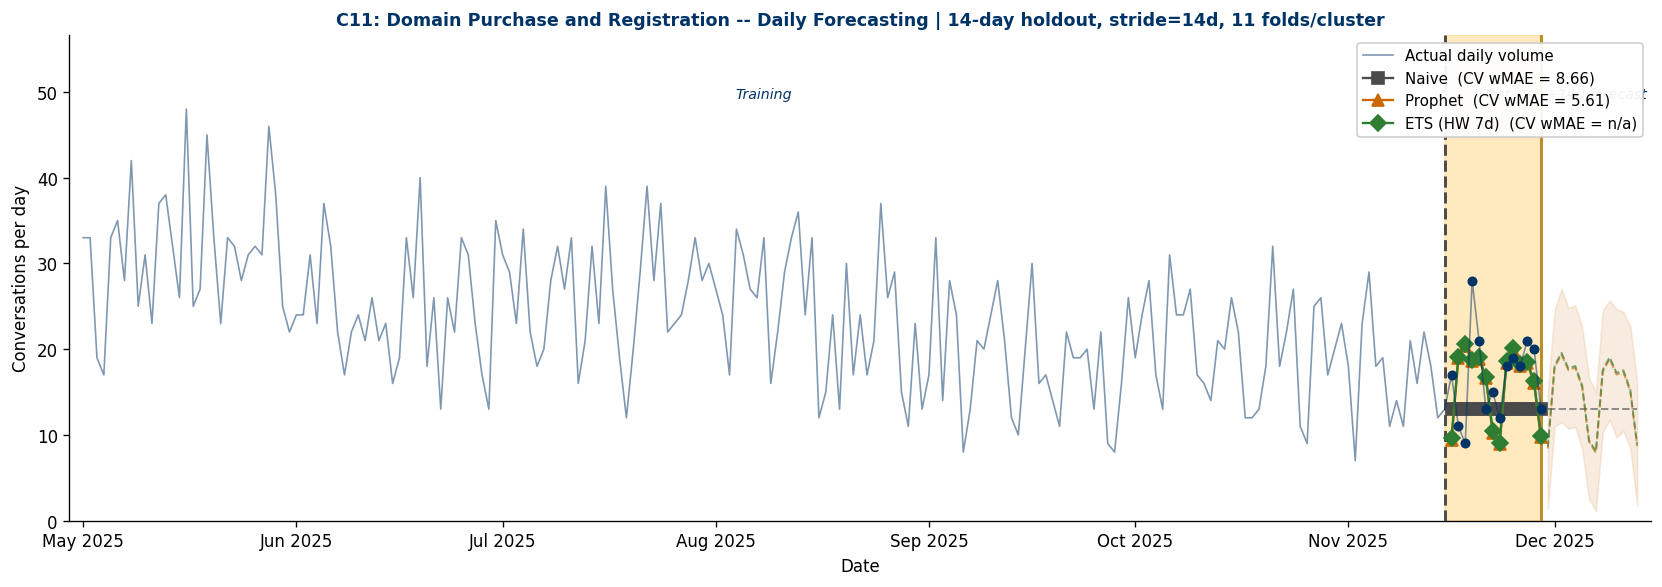

Saved: data/daily_forecast_plot.png


In [22]:
HOLDOUT_D   = 14   
MIN_TRAIN_D = 56   
STRIDE_D    = 14   
all_dates_d = pd.date_range(df['conversation_date'].min(),
                             df['conversation_date'].max(), freq='D')

daily_ct_d = (df.groupby(['conversation_date', 'cluster_id'])
                .size()
                .reset_index(name='day_count'))
daily_ct_d['conversation_date'] = pd.to_datetime(daily_ct_d['conversation_date'])

def get_daily_s(cid):
    s = (daily_ct_d[daily_ct_d.cluster_id == cid][['conversation_date', 'day_count']]
         .rename(columns={'conversation_date': 'ds', 'day_count': 'y'})
         .set_index('ds')
         .reindex(all_dates_d, fill_value=0)
         .reset_index().rename(columns={'index': 'ds'}))
    s['ds'] = pd.to_datetime(s['ds'])
    return s.sort_values('ds').reset_index(drop=True)

total_days = len(all_dates_d)
print(f'Daily range: {all_dates_d[0].date()} to {all_dates_d[-1].date()}  ({total_days} days)')
print(f'CV: min_train={MIN_TRAIN_D}d  holdout={HOLDOUT_D}d  stride={STRIDE_D}d')

daily_rows = []
for cid in top_clusters:
    s = get_daily_s(cid)
    T = len(s)
    fold_starts = list(range(MIN_TRAIN_D, T - HOLDOUT_D + 1, STRIDE_D))
    print(f'C{cid} ({titles_dict.get(cid, "?")[:35]}): {len(fold_starts)} folds')

    for fold, split in enumerate(fold_starts):
        train_d = s.iloc[:split]
        test_d  = s.iloc[split:split + HOLDOUT_D]
        actual  = test_d['y'].values

        naive_p = np.full(HOLDOUT_D, float(train_d['y'].iloc[-1]))

        try:
            mp = Prophet(weekly_seasonality=True, daily_seasonality=False,
                         yearly_seasonality=False, changepoint_prior_scale=0.05,
                         interval_width=0.80)
            mp.fit(train_d[['ds', 'y']])
            fp = mp.make_future_dataframe(periods=HOLDOUT_D, freq='D')
            prophet_p = np.maximum(mp.predict(fp)['yhat'].values[-HOLDOUT_D:], 0)
        except Exception:
            prophet_p = np.full(HOLDOUT_D, np.nan)

        try:
            ets_fit_d = ExponentialSmoothing(
                train_d['y'].values.astype(float),
                trend='add', seasonal='add', seasonal_periods=7,
                initialization_method='estimated'
            ).fit(optimized=True)
            ets_p = np.maximum(ets_fit_d.forecast(HOLDOUT_D), 0)
        except Exception:
            ets_p = np.full(HOLDOUT_D, np.nan)

        daily_rows.append({
            'cluster_id':  cid,
            'fold':        fold,
            'split':       split,
            'naive_mae':   mean_absolute_error(actual, naive_p),
            'prophet_mae': (mean_absolute_error(actual, prophet_p)
                            if not np.any(np.isnan(prophet_p)) else np.nan),
            'ets_mae':     (mean_absolute_error(actual, ets_p)
                            if not np.any(np.isnan(ets_p)) else np.nan),
        })

daily_comp_df = pd.DataFrame(daily_rows)

_dvol = (daily_ct_d[daily_ct_d['cluster_id'].isin(top_clusters)]
         .groupby('cluster_id')['day_count'].sum())
_dvs_d = (_dvol / _dvol.sum()).to_dict()

print('\n-- Daily CV wMAE (conversations / day) --')
daily_wmae = {}
for col, name in [('naive_mae', 'Naive'), ('prophet_mae', 'Prophet'), ('ets_mae', 'ETS (HW-7d)')]:
    grp   = daily_comp_df.groupby('cluster_id')[col].mean()
    vs    = pd.Series(_dvs_d).reindex(grp.index).fillna(0)
    denom = vs.sum()
    wmae  = float((grp * vs).sum() / denom) if denom > 0 else float('nan')
    daily_wmae[name] = wmae
    print(f'  {name:20s}  wMAE = {wmae:.2f} conv/day')

best_d = min(daily_wmae, key=lambda k: daily_wmae[k])
print(f'\n-> Best: {best_d}  (wMAE = {daily_wmae[best_d]:.2f} conv/day)')
daily_comp_df.to_csv(RESULTS_DIR / 'daily_forecasting_comparison.csv', index=False)
print('Saved: data/daily_forecasting_comparison.csv')

cid_plot_d = top_clusters[0]
s_plot_d   = get_daily_s(cid_plot_d)
train_p    = s_plot_d.iloc[:-HOLDOUT_D].copy()
test_p     = s_plot_d.iloc[-HOLDOUT_D:].copy()
fut_ds_d   = pd.date_range(test_p['ds'].iloc[-1] + pd.Timedelta(days=1), periods=14, freq='D')

mp_vis = Prophet(weekly_seasonality=True, daily_seasonality=False,
                 yearly_seasonality=False, changepoint_prior_scale=0.05,
                 interval_width=0.80)
mp_vis.fit(train_p[['ds', 'y']])
fp_vis   = mp_vis.make_future_dataframe(periods=HOLDOUT_D + 14, freq='D')
fcst_vis = mp_vis.predict(fp_vis)
prophet_test_v = np.maximum(fcst_vis['yhat'].values[-(HOLDOUT_D + 14):-14], 0)
prophet_fut_v  = np.maximum(fcst_vis['yhat'].values[-14:], 0)
prophet_lo_v   = np.maximum(fcst_vis['yhat_lower'].values[-14:], 0)
prophet_hi_v   = fcst_vis['yhat_upper'].values[-14:]

ets_ok_v = False
ets_test_v = ets_fut_v = np.full(max(HOLDOUT_D, 14), 0.0)
try:
    ets_vis    = ExponentialSmoothing(
        train_p['y'].values.astype(float),
        trend='add', seasonal='add', seasonal_periods=7,
        initialization_method='estimated').fit(optimized=True)
    ets_full_v = np.maximum(ets_vis.forecast(HOLDOUT_D + 14), 0)
    ets_test_v = ets_full_v[:HOLDOUT_D]
    ets_fut_v  = ets_full_v[HOLDOUT_D:]
    ets_ok_v   = True
except Exception as e:
    print(f'ETS visual failed: {e}')

naive_test_v = np.full(HOLDOUT_D, float(train_p['y'].iloc[-1]))
naive_fut_v  = np.full(14,        float(test_p['y'].iloc[-1]))

fig, ax = plt.subplots(figsize=(14, 5))
train_end_d    = pd.Timestamp(train_p['ds'].iloc[-1])
test_ds_d      = pd.to_datetime(test_p['ds'])
x_start_d      = s_plot_d['ds'].iloc[0] - pd.Timedelta(days=2)
x_end_d        = pd.Timestamp(fut_ds_d[-1]) + pd.Timedelta(days=2)

ax.axvspan(x_start_d, train_end_d,          color='white',   alpha=1.0, zorder=0)
ax.axvspan(train_end_d, test_ds_d.iloc[-1], color='#FFD580', alpha=0.50, zorder=0)
ax.axvspan(test_ds_d.iloc[-1], x_end_d,     color='white',   alpha=1.0, zorder=0)
ax.axvline(train_end_d,        color='#333',     ls='--', lw=1.8, alpha=0.85, zorder=5)
ax.axvline(test_ds_d.iloc[-1], color='#B07A00',  ls='-',  lw=1.8, alpha=0.85, zorder=5)

y_hi_d = s_plot_d['y'].max()
for xpos, label in [
    (train_p['ds'].iloc[len(train_p) // 2], 'Training'),
    (test_ds_d.mean(),                       'Test'),
    (pd.Timestamp(fut_ds_d[7]),              '+14d forecast'),
]:
    ax.text(xpos, y_hi_d * 1.02, label, ha='center', fontsize=8.5,
            color=NAVY, style='italic', va='bottom')

ax.plot(s_plot_d['ds'], s_plot_d['y'], '-', color=NAVY, lw=1.0, alpha=0.5,
        label='Actual daily volume', zorder=8)
ax.plot(test_ds_d, test_p['y'], 'o', color=NAVY, ms=5, zorder=9, label='_nolegend_')

for name, col, mk, test_v, fut_v, ok in [
    ('Naive',        NAIVE_C,   's', naive_test_v,   naive_fut_v,   True),
    ('Prophet',      PROPHET_C, '^', prophet_test_v, prophet_fut_v, True),
    ('ETS (HW 7d)',  ETS_C,     'D', ets_test_v,     ets_fut_v,     ets_ok_v),
]:
    if not ok:
        continue
    name_key = name.split()[0]
    wm = daily_wmae.get(name_key, daily_wmae.get(name, float('nan')))
    wm_str = f'{wm:.2f}' if wm == wm else 'n/a'
    ax.plot(test_ds_d, test_v, marker=mk, color=col, lw=1.4, ms=7, zorder=7,
            label=f'{name}  (CV wMAE = {wm_str})')
    ax.plot(fut_ds_d, fut_v, '--', color=col, lw=1.2, alpha=0.6, zorder=6,
            label='_nolegend_')

ax.fill_between(fut_ds_d, prophet_lo_v, prophet_hi_v, color=PROPHET_C,
                alpha=0.12, label='_nolegend_')

ax.set_xlim(x_start_d, x_end_d)
ax.set_ylim(0, y_hi_d * 1.18)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Conversations per day', fontsize=10)
n_folds_shown = len(list(range(MIN_TRAIN_D, total_days - HOLDOUT_D + 1, STRIDE_D)))
ax.set_title(
    f'C{cid_plot_d}: {titles_dict.get(cid_plot_d, f"Cluster {cid_plot_d}")} -- Daily Forecasting | '
    f'{HOLDOUT_D}-day holdout, stride={STRIDE_D}d, {n_folds_shown} folds/cluster',
    fontsize=10.5, fontweight='bold', color=NAVY)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9, loc='upper right', framealpha=0.94)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'daily_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/daily_forecast_plot.png')


## Daily forecasting: chunk-based

00:28:28 - cmdstanpy - INFO - Chain [1] start processing
00:28:28 - cmdstanpy - INFO - Chain [1] done processing


Daily chunk rows: 5,111  |  date range: 2025-05-01 to 2025-11-29
CV: min_train=56d  holdout=14d  stride=14d
C11 (Domain Purchase and Registration): 11 folds


00:28:28 - cmdstanpy - INFO - Chain [1] start processing
00:28:28 - cmdstanpy - INFO - Chain [1] done processing
00:28:28 - cmdstanpy - INFO - Chain [1] start processing
00:28:29 - cmdstanpy - INFO - Chain [1] done processing
00:28:29 - cmdstanpy - INFO - Chain [1] start processing
00:28:29 - cmdstanpy - INFO - Chain [1] done processing
00:28:29 - cmdstanpy - INFO - Chain [1] start processing
00:28:29 - cmdstanpy - INFO - Chain [1] done processing
00:28:30 - cmdstanpy - INFO - Chain [1] start processing
00:28:30 - cmdstanpy - INFO - Chain [1] done processing
00:28:30 - cmdstanpy - INFO - Chain [1] start processing
00:28:30 - cmdstanpy - INFO - Chain [1] done processing
00:28:30 - cmdstanpy - INFO - Chain [1] start processing
00:28:30 - cmdstanpy - INFO - Chain [1] done processing
00:28:30 - cmdstanpy - INFO - Chain [1] start processing
00:28:30 - cmdstanpy - INFO - Chain [1] done processing
00:28:30 - cmdstanpy - INFO - Chain [1] start processing
00:28:30 - cmdstanpy - INFO - Chain [1]

C8 (Human Agent Escalation Requests): 11 folds


00:28:31 - cmdstanpy - INFO - Chain [1] start processing
00:28:31 - cmdstanpy - INFO - Chain [1] done processing
00:28:32 - cmdstanpy - INFO - Chain [1] start processing
00:28:32 - cmdstanpy - INFO - Chain [1] done processing
00:28:32 - cmdstanpy - INFO - Chain [1] start processing
00:28:32 - cmdstanpy - INFO - Chain [1] done processing
00:28:32 - cmdstanpy - INFO - Chain [1] start processing
00:28:32 - cmdstanpy - INFO - Chain [1] done processing
00:28:33 - cmdstanpy - INFO - Chain [1] start processing
00:28:33 - cmdstanpy - INFO - Chain [1] done processing
00:28:33 - cmdstanpy - INFO - Chain [1] start processing
00:28:33 - cmdstanpy - INFO - Chain [1] done processing
00:28:33 - cmdstanpy - INFO - Chain [1] start processing
00:28:33 - cmdstanpy - INFO - Chain [1] done processing
00:28:33 - cmdstanpy - INFO - Chain [1] start processing
00:28:33 - cmdstanpy - INFO - Chain [1] done processing
00:28:34 - cmdstanpy - INFO - Chain [1] start processing
00:28:34 - cmdstanpy - INFO - Chain [1]

...

C13 (Account and WordPress Login): 11 folds


00:28:41 - cmdstanpy - INFO - Chain [1] start processing
00:28:41 - cmdstanpy - INFO - Chain [1] done processing
00:28:41 - cmdstanpy - INFO - Chain [1] start processing
00:28:41 - cmdstanpy - INFO - Chain [1] done processing
00:28:42 - cmdstanpy - INFO - Chain [1] start processing
00:28:42 - cmdstanpy - INFO - Chain [1] done processing
00:28:42 - cmdstanpy - INFO - Chain [1] start processing
00:28:42 - cmdstanpy - INFO - Chain [1] done processing
00:28:42 - cmdstanpy - INFO - Chain [1] start processing
00:28:42 - cmdstanpy - INFO - Chain [1] done processing
00:28:42 - cmdstanpy - INFO - Chain [1] start processing
00:28:42 - cmdstanpy - INFO - Chain [1] done processing
00:28:43 - cmdstanpy - INFO - Chain [1] start processing
00:28:43 - cmdstanpy - INFO - Chain [1] done processing
00:28:43 - cmdstanpy - INFO - Chain [1] start processing
00:28:43 - cmdstanpy - INFO - Chain [1] done processing
00:28:43 - cmdstanpy - INFO - Chain [1] start processing
00:28:43 - cmdstanpy - INFO - Chain [1]

C15 (AI Builder Layout and Styling): 11 folds


00:28:44 - cmdstanpy - INFO - Chain [1] start processing
00:28:44 - cmdstanpy - INFO - Chain [1] done processing
00:28:45 - cmdstanpy - INFO - Chain [1] start processing
00:28:45 - cmdstanpy - INFO - Chain [1] done processing
00:28:45 - cmdstanpy - INFO - Chain [1] start processing
00:28:45 - cmdstanpy - INFO - Chain [1] done processing
00:28:45 - cmdstanpy - INFO - Chain [1] start processing
00:28:45 - cmdstanpy - INFO - Chain [1] done processing
00:28:46 - cmdstanpy - INFO - Chain [1] start processing
00:28:46 - cmdstanpy - INFO - Chain [1] done processing
00:28:46 - cmdstanpy - INFO - Chain [1] start processing
00:28:46 - cmdstanpy - INFO - Chain [1] done processing
00:28:46 - cmdstanpy - INFO - Chain [1] start processing
00:28:46 - cmdstanpy - INFO - Chain [1] done processing
00:28:46 - cmdstanpy - INFO - Chain [1] start processing
00:28:46 - cmdstanpy - INFO - Chain [1] done processing
00:28:46 - cmdstanpy - INFO - Chain [1] start processing
00:28:46 - cmdstanpy - INFO - Chain [1]


-- Daily Chunk CV wMAE (chunks / day) --
  Naive                 wMAE = 15.12 chunks/day
  Prophet               wMAE = 10.71 chunks/day
  ETS (HW-7d)           wMAE = 11.14 chunks/day

-> Best: Prophet  (wMAE = 10.71 chunks/day)

  [Context] Weekly wMAE=37.02 chunks/wk  ~  5.3 chunks/day equivalent
Saved: data/daily_chunk_forecasting_comparison.csv


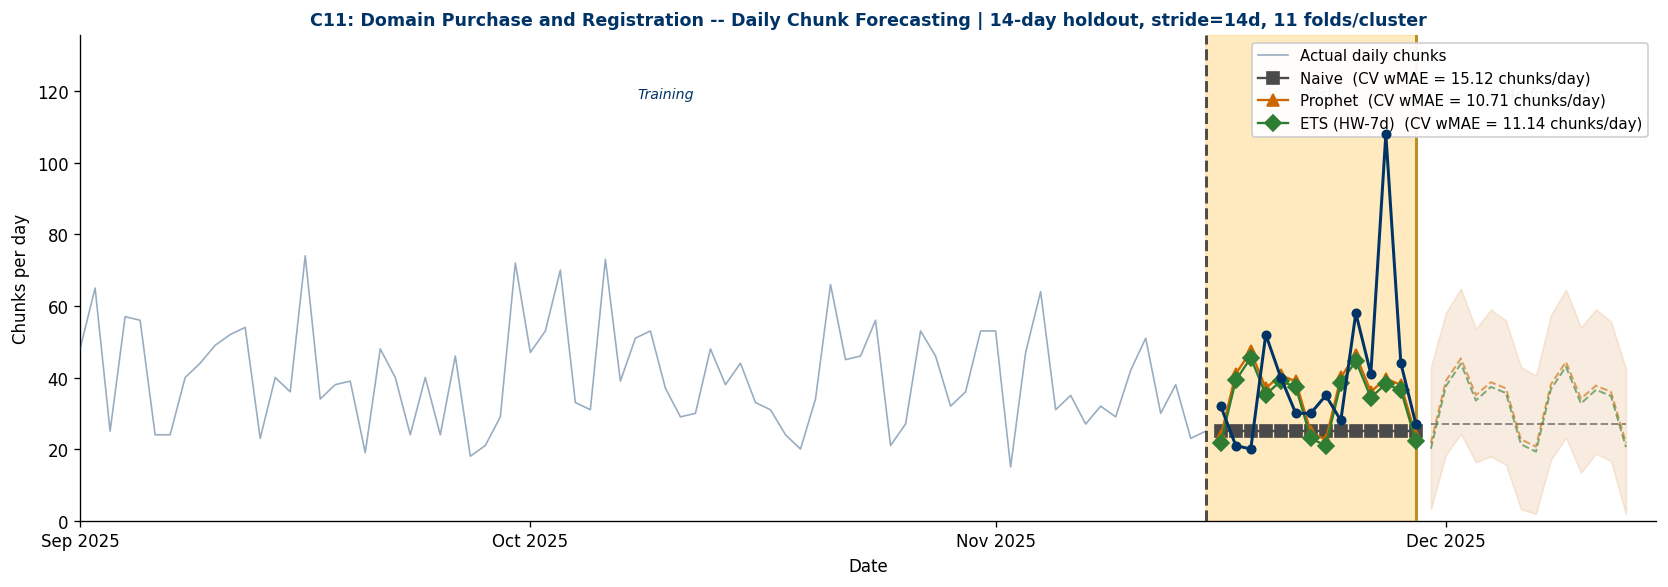

Saved: data/daily_chunk_forecast_plot.png


In [23]:
from sklearn.metrics import r2_score

daily_chunk_bq = client.query(f"""
    SELECT
        DATE(d.conversation_start_date) AS date,
        cl.cluster_id,
        COUNT(*)                         AS chunk_count
    FROM `{bq_table('chunk_cluster_labels')}` cl
    JOIN `{bq_table('conversation_docs')}` d USING (conversation_id)
    WHERE NOT cl.is_noise
    GROUP BY date, cluster_id
    ORDER BY cluster_id, date
""").to_dataframe()
daily_chunk_bq['date'] = pd.to_datetime(daily_chunk_bq['date'])
print(f'Daily chunk rows: {len(daily_chunk_bq):,}  |  '
      f'date range: {daily_chunk_bq["date"].min().date()} to {daily_chunk_bq["date"].max().date()}')

HOLDOUT_D   = 14
MIN_TRAIN_D = 56
STRIDE_D    = 14

all_dates_c = pd.date_range(daily_chunk_bq['date'].min(),
                             daily_chunk_bq['date'].max(), freq='D')

def get_chunk_daily_s(cid):
    s = (daily_chunk_bq[daily_chunk_bq.cluster_id == cid][['date', 'chunk_count']]
         .rename(columns={'date': 'ds', 'chunk_count': 'y'})
         .set_index('ds')
         .reindex(all_dates_c, fill_value=0)
         .reset_index().rename(columns={'index': 'ds'}))
    s['ds'] = pd.to_datetime(s['ds'])
    return s.sort_values('ds').reset_index(drop=True)

total_days_c = len(all_dates_c)
print(f'CV: min_train={MIN_TRAIN_D}d  holdout={HOLDOUT_D}d  stride={STRIDE_D}d')

def _safe_mape(actual, pred):
    """MAPE skipping zero-actual days (avoids division by zero on weekends)."""
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100)

def _seasonal_naive_scale(train_vals, m=7):
    """In-sample lag-m MAE — denominator for MASE."""
    if len(train_vals) <= m:
        return np.nan
    return float(np.mean(np.abs(train_vals[m:] - train_vals[:-m])))

def _fit_ets(y):
    """Fit Holt-Winters ETS; falls back to heuristic init if estimated fails."""
    for init in ('estimated', 'heuristic'):
        try:
            return ExponentialSmoothing(
                y, trend='add', seasonal='add', seasonal_periods=7,
                initialization_method=init
            ).fit(optimized=True)
        except Exception:
            continue
    return None

chunk_daily_rows = []
for cid in top_clusters:
    s = get_chunk_daily_s(cid)
    T = len(s)
    fold_starts = list(range(MIN_TRAIN_D, T - HOLDOUT_D + 1, STRIDE_D))
    print(f'C{cid} ({titles_dict.get(cid, "?")[:35]}): {len(fold_starts)} folds')

    for fold, split in enumerate(fold_starts):
        train_d = s.iloc[:split]
        test_d  = s.iloc[split:split + HOLDOUT_D]
        actual  = test_d['y'].values
        _scale  = _seasonal_naive_scale(train_d['y'].values.astype(float))

        naive_p = np.full(HOLDOUT_D, float(train_d['y'].iloc[-1]))

        try:
            mp = Prophet(weekly_seasonality=True, daily_seasonality=False,
                         yearly_seasonality=False, changepoint_prior_scale=0.05,
                         interval_width=0.80)
            mp.fit(train_d[['ds', 'y']])
            fp = mp.make_future_dataframe(periods=HOLDOUT_D, freq='D')
            prophet_p = np.maximum(mp.predict(fp)['yhat'].values[-HOLDOUT_D:], 0)
        except Exception:
            prophet_p = np.full(HOLDOUT_D, np.nan)

        _ets_fit = _fit_ets(train_d['y'].values.astype(float))
        ets_p = np.maximum(_ets_fit.forecast(HOLDOUT_D), 0) if _ets_fit else np.full(HOLDOUT_D, np.nan)

        _p_ok = not np.any(np.isnan(prophet_p))
        _e_ok = not np.any(np.isnan(ets_p))
        chunk_daily_rows.append({
            'cluster_id':   cid,
            'fold':         fold,
            'split':        split,
            'naive_mae':    mean_absolute_error(actual, naive_p),
            'prophet_mae':  mean_absolute_error(actual, prophet_p) if _p_ok else np.nan,
            'ets_mae':      mean_absolute_error(actual, ets_p)     if _e_ok else np.nan,
            'naive_mape':   _safe_mape(actual, naive_p),
            'prophet_mape': _safe_mape(actual, prophet_p) if _p_ok else np.nan,
            'ets_mape':     _safe_mape(actual, ets_p)     if _e_ok else np.nan,
            'naive_mase':   mean_absolute_error(actual, naive_p)   / _scale if _scale and _scale > 0 else np.nan,
            'prophet_mase': mean_absolute_error(actual, prophet_p) / _scale if (_scale and _scale > 0 and _p_ok) else np.nan,
            'ets_mase':     mean_absolute_error(actual, ets_p)     / _scale if (_scale and _scale > 0 and _e_ok) else np.nan,
            'naive_r2':    r2_score(actual, naive_p),
            'prophet_r2':  r2_score(actual, prophet_p) if _p_ok else np.nan,
            'ets_r2':      r2_score(actual, ets_p)     if _e_ok else np.nan,
        })

chunk_daily_df = pd.DataFrame(chunk_daily_rows)

_cvol_d = (daily_chunk_bq[daily_chunk_bq['cluster_id'].isin(top_clusters)]
           .groupby('cluster_id')['chunk_count'].sum())
_cvs_d  = (_cvol_d / _cvol_d.sum()).to_dict()

print('\n-- Daily Chunk CV wMAE (chunks / day) --')
chunk_daily_wmae = {}
for col, name in [('naive_mae', 'Naive'), ('prophet_mae', 'Prophet'), ('ets_mae', 'ETS (HW-7d)')]:
    grp   = chunk_daily_df.groupby('cluster_id')[col].mean()
    vs    = pd.Series(_cvs_d).reindex(grp.index).fillna(0)
    denom = vs.sum()
    wmae  = float((grp * vs).sum() / denom) if denom > 0 else float('nan')
    chunk_daily_wmae[name] = wmae
    print(f'  {name:20s}  wMAE = {wmae:.2f} chunks/day')

best_c = min(chunk_daily_wmae, key=lambda k: chunk_daily_wmae[k])
print(f'\n-> Best: {best_c}  (wMAE = {chunk_daily_wmae[best_c]:.2f} chunks/day)')
print('\n  [Context] Weekly wMAE=37.02 chunks/wk  ~  5.3 chunks/day equivalent')

chunk_daily_df.to_csv(RESULTS_DIR / 'daily_chunk_forecasting_comparison.csv', index=False)
print('Saved: data/daily_chunk_forecasting_comparison.csv')

cid_plot_c = top_clusters[0]
s_vis      = get_chunk_daily_s(cid_plot_c)
train_cv   = s_vis.iloc[:-HOLDOUT_D].copy()
test_cv    = s_vis.iloc[-HOLDOUT_D:].copy()
fut_ds_c   = pd.date_range(test_cv['ds'].iloc[-1] + pd.Timedelta(days=1), periods=14, freq='D')

mp_c = Prophet(weekly_seasonality=True, daily_seasonality=False,
               yearly_seasonality=False, changepoint_prior_scale=0.05,
               interval_width=0.80)
mp_c.fit(train_cv[['ds', 'y']])
fp_c   = mp_c.make_future_dataframe(periods=HOLDOUT_D + 14, freq='D')
fcst_c = mp_c.predict(fp_c)
prophet_test_c = np.maximum(fcst_c['yhat'].values[-(HOLDOUT_D + 14):-14], 0)
prophet_fut_c  = np.maximum(fcst_c['yhat'].values[-14:], 0)
prophet_lo_c   = np.maximum(fcst_c['yhat_lower'].values[-14:], 0)
prophet_hi_c   = fcst_c['yhat_upper'].values[-14:]

ets_ok_c = False
ets_test_c = ets_fut_c = np.zeros(max(HOLDOUT_D, 14))
_ets_vis = _fit_ets(train_cv['y'].values.astype(float))
if _ets_vis:
    ets_full_c = np.maximum(_ets_vis.forecast(HOLDOUT_D + 14), 0)
    ets_test_c = ets_full_c[:HOLDOUT_D]
    ets_fut_c  = ets_full_c[HOLDOUT_D:]
    ets_ok_c   = True
else:
    print('ETS visual failed: both initialization methods failed')

naive_test_c = np.full(HOLDOUT_D, float(train_cv['y'].iloc[-1]))
naive_fut_c  = np.full(14,        float(test_cv['y'].iloc[-1]))

fig, ax = plt.subplots(figsize=(14, 5))
train_end_c    = pd.Timestamp(train_cv['ds'].iloc[-1])
test_ds_c      = pd.to_datetime(test_cv['ds'])
x_start_c      = s_vis['ds'].iloc[0] - pd.Timedelta(days=2)
x_end_c        = pd.Timestamp(fut_ds_c[-1]) + pd.Timedelta(days=2)

ax.axvspan(x_start_c, train_end_c,           color='white',   alpha=1.0, zorder=0)
ax.axvspan(train_end_c, test_ds_c.iloc[-1],  color='#FFD580', alpha=0.50, zorder=0)
ax.axvspan(test_ds_c.iloc[-1], x_end_c,      color='white',   alpha=1.0, zorder=0)
ax.axvline(train_end_c,        color='#333',    ls='--', lw=1.8, alpha=0.85, zorder=5)
ax.axvline(test_ds_c.iloc[-1], color='#B07A00', ls='-',  lw=1.8, alpha=0.85, zorder=5)

y_hi_c = s_vis['y'].max()
for xpos, label in [
    (pd.Timestamp('2025-10-10'),               'Training'),
    (test_ds_c.mean(),                         'Test'),
    (pd.Timestamp(fut_ds_c[7]),                '+14d forecast'),
]:
    ax.text(xpos, y_hi_c * 1.02, label, ha='center', fontsize=8.5,
            color=NAVY, style='italic', va='bottom')

ax.plot(train_cv['ds'], train_cv['y'], '-', color=NAVY, lw=1.0, alpha=0.4,
        label='Actual daily chunks', zorder=8)
ax.plot(test_ds_c, test_cv['y'], '-o', color=NAVY, lw=1.8, alpha=1.0, ms=5, zorder=10, label='_nolegend_')

for name, col, mk, test_v, fut_v, ok in [
    ('Naive',        NAIVE_C,   's', naive_test_c,   naive_fut_c,   True),
    ('Prophet',      PROPHET_C, '^', prophet_test_c, prophet_fut_c, True),
    ('ETS (HW-7d)', ETS_C,     'D', ets_test_c,     ets_fut_c,     ets_ok_c),
]:
    if not ok:
        continue
    wm = chunk_daily_wmae.get(name, float('nan'))
    wm_str = f'{wm:.2f}' if wm == wm else 'n/a'
    ax.plot(test_ds_c, test_v, marker=mk, color=col, lw=1.4, ms=7, zorder=7,
            label=f'{name}  (CV wMAE = {wm_str} chunks/day)')
    ax.plot(fut_ds_c, fut_v, '--', color=col, lw=1.2, alpha=0.6, zorder=6,
            label='_nolegend_')

ax.fill_between(fut_ds_c, prophet_lo_c, prophet_hi_c, color=PROPHET_C,
                alpha=0.12, label='_nolegend_')

ax.set_xlim(pd.Timestamp('2025-09-01'), x_end_c)
ax.set_ylim(0, y_hi_c * 1.18)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Chunks per day', fontsize=10)
n_folds_c = len(list(range(MIN_TRAIN_D, total_days_c - HOLDOUT_D + 1, STRIDE_D)))
ax.set_title(
    f'C{cid_plot_c}: {titles_dict.get(cid_plot_c, f"Cluster {cid_plot_c}")} -- Daily Chunk Forecasting | '
    f'{HOLDOUT_D}-day holdout, stride={STRIDE_D}d, {n_folds_c} folds/cluster',
    fontsize=10.5, fontweight='bold', color=NAVY)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9, loc='upper right', framealpha=0.94)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'daily_chunk_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/daily_chunk_forecast_plot.png')


In [25]:
def _wmetric(col):
    grp = chunk_daily_df.groupby('cluster_id')[col].mean()
    vs  = pd.Series(_cvs_d).reindex(grp.index).fillna(0)
    d   = vs.sum()
    return float((grp * vs).sum() / d) if d > 0 else float('nan')

metrics_full = {
    'Naive': {
        'MAE':    chunk_daily_df.groupby('cluster_id')['naive_mae'].mean().mean(),
        'wMAE':   chunk_daily_wmae['Naive'],
        'MAPE %': _wmetric('naive_mape'),
        'MASE':   _wmetric('naive_mase'),
        'R²':     _wmetric('naive_r2'),
    },
    'Prophet': {
        'MAE':    chunk_daily_df.groupby('cluster_id')['prophet_mae'].mean().mean(),
        'wMAE':   chunk_daily_wmae['Prophet'],
        'MAPE %': _wmetric('prophet_mape'),
        'MASE':   _wmetric('prophet_mase'),
        'R²':     _wmetric('prophet_r2'),
    },
    'ETS (HW-7d)': {
        'MAE':    chunk_daily_df.groupby('cluster_id')['ets_mae'].mean().mean(),
        'wMAE':   chunk_daily_wmae['ETS (HW-7d)'],
        'MAPE %': _wmetric('ets_mape'),
        'MASE':   _wmetric('ets_mase'),
        'R²':     _wmetric('ets_r2'),
    },
}

print('Daily Chunk Forecasting — CV Metrics (6 clusters, 11 folds each)')
print(f"  {'Model':<14} {'MAE':>8} {'wMAE':>8} {'MAPE %':>8} {'MASE':>8} {'R²':>8}")
for mname, vals in metrics_full.items():
    print(
        f"  {mname:<14}"
        f"  {vals['MAE']:>6.2f}"
        f"  {vals['wMAE']:>6.2f}"
        f"  {vals['MAPE %']:>6.1f}"
        f"  {vals['MASE']:>6.3f}"
        f"  {vals['R²']:>6.3f}"
    )

print()

Daily Chunk Forecasting — CV Metrics (6 clusters, 11 folds each)
  Model               MAE     wMAE   MAPE %     MASE       R²
  Naive            15.18   15.12    50.5   1.047  -1.280
  Prophet          10.64   10.71    31.6   0.736  -0.066
  ETS (HW-7d)      11.13   11.14    32.4   0.753  -0.185

